# Adversarial Machine Learning: Attacking & Defending Protocol Classifiers

> **Term Project — CS60099: Internet and Applications**  
> **Department of Computer Science and Engineering, Indian Institute of Technology Kharagpur**  
> **Topic 9: Adversarial ML: Attacking & Defending Protocol Classifiers**

---

## Executive Summary & Project Overview

Machine learning models deployed in network monitoring and Software-Defined Networking (SDN) architectures are increasingly tasked with **protocol classification**—identifying the underlying transport and application protocols governing network flows. However, deep neural networks and traditional machine learning classifiers are notoriously vulnerable to **adversarial evasion attacks**: small, intentionally crafted perturbations in feature space that induce severe classification errors while preserving network flow utility.

This project implements a complete, rigorous, and leakage-free research pipeline addressing both the offensive and defensive dimensions of adversarial protocol classification:
1. **Target Task**: Multiclass network protocol classification using the **UNSW-NB15** dataset (`proto` target).
2. **Leakage Prevention**: Elimination of target leakage (`Label`, `attack_cat`) and identifier/proxy shortcuts (`srcip`, `dstip`, `sport`, `dsport`, `Stime`, `Ltime`).
3. **Four Baseline Architectures**:
   - **Random Forest** (non-differentiable ensemble)
   - **Linear SVM** (scalable linear convex boundary)
   - **1D Convolutional Neural Network (CNN)** (differentiable deep feature extractor)
   - **Long Short-Term Memory (LSTM)** (sequential feature processor with explicit methodological documentation)
4. **Adversarial Evasion Attacks**:
   - **True FGSM (Fast Gradient Sign Method)**: Exact gradient-directed perturbation $\epsilon \cdot \text{sign}(\nabla_x \mathcal{L})$.
   - **True PGD (Projected Gradient Descent)**: Iterative projected gradient ascent inside the $L_\infty$ ball.
   - **Feature-Space Invariance Masking**: Perturbations strictly isolated to continuous flow features; categorical one-hot indicators remain invariant.
   - **Transfer-Based Black-Box Attack**: Evaluating gradient-derived adversarial examples from surrogate 1D CNN against gradient-inaccessible Random Forest and Linear SVM.
5. **Defense Mechanisms**:
   - **Adversarial Training**: Augmented min-max optimization training on clean and gradient-perturbed samples.
   - **Input Sanitization**: Clipping standardized continuous features to $[-3, +3]$.
6. **Programmatic Evaluation**: Dynamic generation of Tables 1, 2, and 3, confusion matrices, learning curves, and robustness trade-off plots.


## 1. Google Colab Execution Guide

To execute this notebook in **Google Colab**:

### 1.1 Enable GPU Acceleration
1. Navigate to **Runtime** $\to$ **Change runtime type**.
2. Select **T4 GPU** (or any available hardware accelerator) and click **Save**.

### 1.2 Placing Dataset in Colab Temporary Session Storage (No Google Drive Required)
If you do **not** want to mount Google Drive, you can place the dataset directly into Colab's temporary `/content/` storage:

**Recommended Method (Fastest — 143MB Zip Upload):**
1. In Colab, click the **Folder icon (Files)** on the left sidebar.
2. Click the **Upload to session storage** button (page with upward arrow) and select:
   `unsw-nb15-complete.zip` (located inside `./dataset/UNSW-NB15/` in this repository, ~143 MB).
3. Run the **Extraction Helper Cell** below. It will automatically extract the 5 dataset files into `/content/dataset/UNSW-NB15/` in ~5 seconds!

*(Alternatively, you can manually create the folder `/content/dataset/UNSW-NB15/` in the left panel and drag-and-drop the uncompressed CSVs, but uploading the single compressed zip is much faster and less prone to browser upload timeouts).*


In [1]:
# =====================================================================
# [OPTIONAL HELPER] Session Storage Dataset Extractor
# Run this cell if you uploaded unsw-nb15-complete.zip to /content/
# =====================================================================
import os
import zipfile
from pathlib import Path

colab_zip = Path('/content/unsw-nb15-complete.zip')
target_extract_dir = Path('/content/dataset/UNSW-NB15')

if colab_zip.exists() and not (target_extract_dir / 'NUSW-NB15_features.csv').exists():
    print(f"[*] Found {colab_zip.name}. Extracting to {target_extract_dir}...")
    target_extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(colab_zip, 'r') as zip_ref:
        zip_ref.extractall(target_extract_dir)
    print(f"[*] Extraction complete! Extracted {len(list(target_extract_dir.glob('*.csv')))} files.")
elif (target_extract_dir / 'NUSW-NB15_features.csv').exists():
    print(f"[*] Dataset already present at: {target_extract_dir}")
else:
    print(f"[*] No zip found at {colab_zip}. Proceeding to dataset directory resolver.")


[*] Found unsw-nb15-complete.zip. Extracting to /content/dataset/UNSW-NB15...
[*] Extraction complete! Extracted 5 files.


## 2. Literature Survey

Adversarial machine learning investigates the vulnerabilities of statistical learning algorithms in adversarial environments. In network traffic classification, this vulnerability presents severe security and operational challenges.

### 2.1 Foundational Adversarial Machine Learning
- **Discovery of Adversarial Examples**: Szegedy et al. (2013) demonstrated that deep neural networks learn non-intuitive, discontinuous input-output mappings, where imperceptible worst-case perturbations cause arbitrary misclassifications.
- **The Fast Gradient Sign Method (FGSM)**: Goodfellow, Shlens, and Szegedy (2014) introduced the *linearity hypothesis*, arguing that adversarial vulnerability stems from high-dimensional linear behavior rather than extreme non-linearity. They proposed the single-step $L_\infty$-bounded attack:
  $$\mathbf{x}_{adv} = \mathbf{x} + \epsilon \cdot \text{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\mathbf{\theta}, \mathbf{x}, y)\right)$$
- **Projected Gradient Descent (PGD)**: Madry et al. (2018) formulated adversarial robustness as a robust min-max optimization problem:
  $$\min_\theta \mathbb{E}_{(\mathbf{x}, y) \sim \mathcal{D}} \left[ \max_{\mathbf{\delta} \in \mathcal{S}} \mathcal{L}(\mathbf{\theta}, \mathbf{x} + \mathbf{\delta}, y) \right]$$
  PGD iteratively applies gradient ascent with step size $\alpha$ and projects the iterate back onto the $\epsilon$-ball $\mathcal{S}$, acting as a universal first-order adversary.
- **Jacobian Saliency & Black-Box Transferability**: Papernot et al. (2016, 2017) introduced Jacobian-based Saliency Map Attacks (JSMA) and demonstrated that adversarial perturbations transfer across entirely disparate model architectures (e.g., from neural networks to support vector machines and decision trees) due to shared decision boundary alignments.

### 2.2 Adversarial ML in Network Traffic & Protocol Classification
- **Brittleness of Traffic Classifiers**: Usama et al. (2019) and Sadeghzadeh et al. (2021) evaluated white-box and black-box evasion attacks on flow-based network traffic classifiers, finding that minor perturbations in statistical flow features (packet counts, inter-arrival times, byte lengths) induce catastrophic accuracy degradation.
- **Problem Space vs. Feature Space Dilemma**: Pierazzi et al. (2020) formalized the critical dichotomy between *feature-space* perturbations and *problem-space* transformations. In network protocols, an adversary cannot arbitrarily alter features without breaking protocol state machines, checksums, or TCP connection handshakes. Hence, feature-space perturbations represent an upper-bound theoretical evasion capability.
- **Defenses in Network Security**: Tramer et al. (2018) showed that standard adversarial training often suffers from gradient masking, advocating for multi-model ensemble adversarial training. Meng & Chen (2017) proposed input sanitization and autoencoding to project perturbed inputs back onto the benign data manifold.


In [2]:
# =====================================================================
# Cell 1: Environment Setup, Path Resolver & Reproducibility
# =====================================================================
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set matplotlib & seaborn formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Reproducibility Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

# Hardware Device Detection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Hardware Acceleration Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"[*] GPU Name: {torch.cuda.get_device_name(0)}")

# Configurable Dataset Directory Resolver (Colab, Drive, Local) with Auto-Discovery
CANDIDATE_PATHS = [
    Path('/content/dataset/UNSW-NB15'),
    Path('/content/UNSW-NB15'),
    Path('/content'),
    Path('./dataset/UNSW-NB15'),
    Path('./UNSW-NB15'),
    Path('../dataset/UNSW-NB15'),
    Path('.')
]

DATASET_DIR = None
for p in CANDIDATE_PATHS:
    if p.exists() and (p / 'NUSW-NB15_features.csv').exists():
        DATASET_DIR = p.resolve()
        break

# Recursive search if not in immediate candidate paths
if DATASET_DIR is None:
    for root in [Path('/content'), Path('.')]:
        if root.exists():
            matches = list(root.rglob('NUSW-NB15_features.csv'))
            if matches:
                DATASET_DIR = matches[0].parent.resolve()
                break

# Auto-extract any unsw zip if found in /content or current directory
if DATASET_DIR is None:
    for root in [Path('/content'), Path('.')]:
        if root.exists():
            for zip_p in list(root.glob('*.zip')) + list(root.rglob('*unsw*.zip')):
                try:
                    import zipfile
                    with zipfile.ZipFile(zip_p, 'r') as zf:
                        if any('NUSW-NB15_features.csv' in n for n in zf.namelist()):
                            target_ext = Path('/content/dataset/UNSW-NB15')
                            target_ext.mkdir(parents=True, exist_ok=True)
                            print(f"[*] Auto-extracting '{zip_p.name}' to {target_ext}...")
                            zf.extractall(target_ext)
                            matches = list(target_ext.rglob('NUSW-NB15_features.csv'))
                            if matches:
                                DATASET_DIR = matches[0].parent.resolve()
                                break
                except Exception:
                    pass
            if DATASET_DIR is not None:
                break

if DATASET_DIR is None:
    DATASET_DIR = Path('/content/dataset/UNSW-NB15')
    print(f"[!] Note: Dataset folder not yet found. Defaulting to: {DATASET_DIR}")
    print("[!] In Colab, upload 'unsw-nb15-complete.zip' to /content/ and run the helper cell above!")
else:
    print(f"[*] Verified Dataset Directory: {DATASET_DIR}")


[*] Hardware Acceleration Device: cuda
[*] GPU Name: Tesla T4
[*] Verified Dataset Directory: /content/dataset/UNSW-NB15


In [3]:
# =====================================================================
# Cell 2: Central Hyperparameter & Experiment Configuration
# =====================================================================
CONFIG = {
    'RANDOM_STATE': 42,

    # Dataset Ingestion Parameters
    'MAX_ROWS_PER_SHARD': 50_000,      # Randomized rows sampled per flow shard
    'MIN_SAMPLES_PER_PROTOCOL': 20,    # Minimum class count threshold to ensure stable stratification
    'MAX_SAMPLES_PER_PROTOCOL': 1_500, # Per-protocol quota cap to prevent majority class domination
    'TEST_SIZE': 0.20,                 # 80/20 train/test split ratio

    # Neural Network Training Parameters
    'BATCH_SIZE': 128,
    'EPOCHS': 15,
    'PATIENCE': 3,
    'LEARNING_RATE': 1e-3,
    'DROPOUT_RATE': 0.25,

    # Adversarial Attack Parameters
    'FGSM_EPSILONS': [0.01, 0.05, 0.10, 0.20], # Multi-epsilon evaluation grid
    'PGD_EPSILON': 0.10,                        # Default PGD epsilon
    'PGD_ALPHA': 0.02,                          # PGD iterative step size
    'PGD_STEPS': 10,                            # Number of PGD iterations

    # Defense Parameters
    'ADV_TRAIN_EPSILON': 0.10,                  # Epsilon used during adversarial retraining
    'ADV_TRAIN_EPOCHS': 12,                     # Epochs for adversarial training
    'SANITIZATION_SIGMA': 3.0                   # Standardized continuous clipping threshold [-3.0, +3.0]
}

print("[*] Configuration parameters loaded successfully.")


[*] Configuration parameters loaded successfully.


## 3. Experimental Settings & Dataset Schema

### 3.1 Experimental Configuration Summary
- **Dataset**: UNSW-NB15 network traffic flow dataset
- **Classification Target**: `proto` (Multiclass network transaction protocol)
- **Models Evaluated**:
  1. **Random Forest**: Non-differentiable ensemble baseline
  2. **Linear SVM**: Scalable linear convex classifier (`LinearSVC`)
  3. **1D CNN**: Differentiable deep neural network (surrogate & target)
  4. **LSTM**: Sequence-oriented deep architecture on tabular feature vector
- **Adversarial Attacks**:
  - **White-box FGSM** (Fast Gradient Sign Method)
  - **White-box PGD** (Projected Gradient Descent)
  - **Transfer-based black-box attack** (Surrogate: 1D CNN $\to$ Targets: Random Forest, Linear SVM)
- **Defenses Evaluated**:
  - **FGSM adversarial training** (on-the-fly min-max augmented retraining)
  - **Input sanitization** (clipping standardized continuous features to $[-3, +3]$)
- **Important Methodological Constraints**:
  - **Inference-time evasion attacks only**: Attacks occur exclusively during evaluation; training data is not poisoned.
  - **Feature-space perturbations only**: Modifications apply to standardized continuous flow metrics bounded within $L_\infty$ balls.
  - **Fixed random seed for reproducibility**: `RANDOM_STATE = 42` is strictly maintained across sampling, splits, and initializations.
  - **Sampled subset for Colab feasibility**: A reproducible random subset of UNSW-NB15 is extracted to ensure stable execution within Colab memory limits.

---

### 3.2 Target Selection: `proto`
- **Field Definition**: Column No. 5 (`proto`) represents the authentic **Transaction Protocol** (e.g., `tcp`, `udp`, `arp`, `ospf`, `icmp`, `sctp`).
- **Strict Scope**: We classify `proto`. We do **NOT** infer protocols from port numbers, nor do we classify intrusion categories (`attack_cat`) or binary intrusion labels (`Label`).

### 3.3 Target Leakage & Shortcut Prevention
To ensure models learn real transport protocol dynamics rather than opportunistic shortcuts, we strictly drop:
1. **Target Leakage Fields**: `attack_cat` and `Label` (intrusion attributes irrelevant to protocol identification).
2. **Identifier & Topology Shortcuts**: `srcip` and `dstip` (preventing host IP memorization).
3. **Port-Proxy Shortcuts**: `sport` and `dsport` (well-known ports directly disclose protocols, circumventing flow analysis).
4. **Capture-Time Artifacts**: `Stime` and `Ltime` (timestamps reflecting experimental capture phases).

### 3.4 Retained Flow Features (40 Features)
- **Categorical Flow Features (2)**: `state`, `service`.
- **Continuous Numerical Flow Features (38)**: Duration (`dur`), packet counts (`Spkts`, `Dpkts`), byte volumes (`sbytes`, `dbytes`), TTL metrics (`sttl`, `dttl`), packet loss (`sloss`, `dloss`), load/throughput (`Sload`, `Dload`), TCP window advertisements (`swin`, `dwin`), sequence numbers (`stcpb`, `dtcpb`), packet sizes (`smeansz`, `dmeansz`), jitter (`Sjit`, `Djit`), inter-packet arrival times (`Sintpkt`, `Dintpkt`), TCP handshake round-trip times (`tcprtt`, `synack`, `ackdat`), and neighborhood connection counts (`ct_state_ttl`, `ct_srv_src`, etc.).

---

### 3.5 Note on Dataset Sampling & Colab Runtime Constraints
The complete UNSW-NB15 archive spans 4 raw CSV shards comprising over 2.5 million flow records (>600 MB raw text). Loading the entire uncompressed dataset into memory simultaneously can exhaust RAM and cause kernel termination in standard Google Colab runtimes.

Therefore, a **reproducible random subset** of up to `MAX_ROWS_PER_SHARD = 50,000` rows is sampled uniformly from each shard using chunked reservoir sampling with a fixed random seed. This ensures unbiased representation across the entire capture window while keeping memory usage modest. The sampled records are subsequently balanced using protocol frequency thresholds and per-class quota limits.


In [4]:
# =====================================================================
# Cell 3: Dataset Ingestion with Randomized Sampling & Balanced Protocols
# =====================================================================
def load_and_audit_unsw_dataset(dataset_dir, config):
    """
    Loads UNSW-NB15 flow files, applies schema from NUSW-NB15_features.csv,
    enforces protocol target extraction, and implements memory-efficient
    reproducible random sampling and protocol quota balancing.
    """
    dataset_dir = Path(dataset_dir)
    feature_file = dataset_dir / 'NUSW-NB15_features.csv'

    # Auto-recovery if feature_file is not at dataset_dir
    if not feature_file.exists():
        print(f"[!] Schema not found at {feature_file}. Searching system...")
        found_dir = None
        for root in [Path('/content'), Path('.')]:
            if root.exists():
                matches = list(root.rglob('NUSW-NB15_features.csv'))
                if matches:
                    found_dir = matches[0].parent.resolve()
                    break
        if found_dir is None:
            # Check for any zip archive and auto-extract
            for root in [Path('/content'), Path('.')]:
                if root.exists():
                    for zip_p in list(root.glob('*.zip')) + list(root.rglob('*unsw*.zip')):
                        try:
                            import zipfile
                            with zipfile.ZipFile(zip_p, 'r') as zf:
                                if any('NUSW-NB15_features.csv' in n for n in zf.namelist()):
                                    target_ext = Path('/content/dataset/UNSW-NB15')
                                    target_ext.mkdir(parents=True, exist_ok=True)
                                    print(f"[*] Auto-extracting '{zip_p.name}' -> {target_ext}...")
                                    zf.extractall(target_ext)
                                    matches = list(target_ext.rglob('NUSW-NB15_features.csv'))
                                    if matches:
                                        found_dir = matches[0].parent.resolve()
                                        break
                        except Exception:
                            pass
                    if found_dir is not None:
                        break
        if found_dir is not None:
            dataset_dir = found_dir
            feature_file = dataset_dir / 'NUSW-NB15_features.csv'
            print(f"[*] Auto-resolved dataset directory to: {dataset_dir}")
        else:
            contents = [p.name for p in Path('/content').iterdir()] if Path('/content').exists() else []
            err_msg = (
                f"[!] ERROR: 'NUSW-NB15_features.csv' not found at {dataset_dir} or anywhere in /content/. "
                f"Current /content/ contents: {contents}. "
                "Please upload 'unsw-nb15-complete.zip' into Colab and run the helper extraction cell above."
            )
            raise FileNotFoundError(err_msg)

    schema_df = pd.read_csv(feature_file, encoding='latin1')
    schema_df.columns = [c.strip() for c in schema_df.columns]
    column_names = schema_df['Name'].astype(str).str.strip().tolist()

    flow_files = sorted(dataset_dir.glob('UNSW-NB15_*.csv'))
    if not flow_files:
        flow_files = sorted(dataset_dir.rglob('UNSW-NB15_*.csv'))
    if not flow_files:
        raise FileNotFoundError(f"No UNSW-NB15_*.csv data files found in: {dataset_dir}")

    print(f"[*] Found schema with {len(column_names)} columns and {len(flow_files)} data shards:")
    for f in flow_files:
        print(f"    - {f.name} ({f.stat().st_size / (1024**2):.1f} MB)")

    # Memory-efficient randomized reservoir sampling across shards
    dfs = []
    rows_per_file = config['MAX_ROWS_PER_SHARD']
    for shard_idx, f in enumerate(flow_files):
        print(f"[*] Randomly sampling up to {rows_per_file:,} rows from {f.name}...")
        rng = np.random.default_rng(config['RANDOM_STATE'] + shard_idx)
        reservoir = None

        # Read in chunks to avoid loading full 700k-row CSV into memory
        for chunk in pd.read_csv(f, header=None, names=column_names, chunksize=100_000, low_memory=False):
            chunk['_sample_key'] = rng.random(len(chunk))
            sampled_chunk = chunk.nsmallest(rows_per_file, '_sample_key')
            if reservoir is None:
                reservoir = sampled_chunk
            else:
                reservoir = pd.concat([reservoir, sampled_chunk], ignore_index=True).nsmallest(rows_per_file, '_sample_key')

        if reservoir is not None:
            shard_sample = reservoir.drop(columns=['_sample_key']).reset_index(drop=True)
            dfs.append(shard_sample)
            print(f"    -> Sampled {len(shard_sample):,} rows from {f.name}")

    raw_df = pd.concat(dfs, ignore_index=True)
    print(f"[*] Aggregated randomized raw records: {len(raw_df):,}")

    # Standardize protocol labels (strip whitespace, lowercase)
    raw_df['proto'] = raw_df['proto'].astype(str).str.strip().str.lower()

    # Target Leakage and Identifier Removal
    TARGET = 'proto'
    LEAKAGE_COLUMNS = ['attack_cat', 'Label']
    PROXY_COLUMNS = ['srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime']

    to_drop = [TARGET] + LEAKAGE_COLUMNS + PROXY_COLUMNS
    FEATURE_COLUMNS = [c for c in column_names if c not in to_drop]
    CATEGORICAL_FEATURES = [c for c in FEATURE_COLUMNS if c in ['state', 'service']]
    NUMERICAL_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

    print(f"[*] Feature Partitioning:")
    print(f"    - Target: {TARGET}")
    print(f"    - Excluded Leakage / Proxy columns: {LEAKAGE_COLUMNS + PROXY_COLUMNS}")
    print(f"    - Continuous Numerical features: {len(NUMERICAL_FEATURES)}")
    print(f"    - Categorical features: {len(CATEGORICAL_FEATURES)}")

    # Protocol Class Frequency Filtering (ensuring minimum count for valid stratification)
    proto_counts = raw_df['proto'].value_counts()
    valid_protocols = proto_counts[proto_counts >= config['MIN_SAMPLES_PER_PROTOCOL']].index.tolist()
    print(f"[*] Protocol class count filtering: retained {len(valid_protocols)} protocols with >= {config['MIN_SAMPLES_PER_PROTOCOL']} samples.")

    filtered_df = raw_df[raw_df['proto'].isin(valid_protocols)].copy()

    # Quota sampling per protocol to prevent majority class (tcp/udp) from completely dominating
    max_per_proto = config['MAX_SAMPLES_PER_PROTOCOL']
    balanced_df = (
        filtered_df.groupby('proto', group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max_per_proto), random_state=config['RANDOM_STATE']))
        .reset_index(drop=True)
    )

    # Replace infinities with NaN and coerce clean data types
    for c in NUMERICAL_FEATURES:
        balanced_df[c] = pd.to_numeric(balanced_df[c], errors='coerce')
    for c in CATEGORICAL_FEATURES:
        balanced_df[c] = balanced_df[c].astype(str).str.strip()

    balanced_df[NUMERICAL_FEATURES] = balanced_df[NUMERICAL_FEATURES].replace([np.inf, -np.inf], np.nan)

    print(f"[*] Final balanced dataset shape: {balanced_df.shape}")
    print(f"[*] Final protocol distribution (Top 10):")
    print(balanced_df['proto'].value_counts().head(10))

    return balanced_df, FEATURE_COLUMNS, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, TARGET

# Execute dataset ingestion
df_clean, FEATURE_COLS, NUMERICAL_COLS, CATEGORICAL_COLS, TARGET_COL = load_and_audit_unsw_dataset(DATASET_DIR, CONFIG)


[*] Found schema with 49 columns and 4 data shards:
    - UNSW-NB15_1.csv (161.2 MB)
    - UNSW-NB15_2.csv (157.6 MB)
    - UNSW-NB15_3.csv (147.4 MB)
    - UNSW-NB15_4.csv (93.1 MB)
[*] Randomly sampling up to 50,000 rows from UNSW-NB15_1.csv...
    -> Sampled 50,000 rows from UNSW-NB15_1.csv
[*] Randomly sampling up to 50,000 rows from UNSW-NB15_2.csv...
    -> Sampled 50,000 rows from UNSW-NB15_2.csv
[*] Randomly sampling up to 50,000 rows from UNSW-NB15_3.csv...
    -> Sampled 50,000 rows from UNSW-NB15_3.csv
[*] Randomly sampling up to 50,000 rows from UNSW-NB15_4.csv...
    -> Sampled 50,000 rows from UNSW-NB15_4.csv
[*] Aggregated randomized raw records: 200,000
[*] Feature Partitioning:
    - Target: proto
    - Excluded Leakage / Proxy columns: ['attack_cat', 'Label', 'srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime']
    - Continuous Numerical features: 38
    - Categorical features: 2
[*] Protocol class count filtering: retained 16 protocols with >= 20 samples.
[*] Final

/tmp/ipykernel_958/2908441254.py:126: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_proto), random_state=config['RANDOM_STATE']))


## 4. Leakage-Free Preprocessing Pipeline & Stratification

To ensure zero information leakage from the test distribution into the training pipeline:
1. **Partition First**: An 80:20 stratified split is created using `train_test_split(..., stratify=y)` **before** fitting any scaler or imputer.
2. **Training-Only Fitting**:
   - Continuous numerical features: Imputed with median, standardized with `StandardScaler` fit strictly on `X_train`.
   - Categorical features (`state`, `service`): Imputed with most frequent, encoded with `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` fit strictly on `X_train`.
3. **Continuous Feature Invariance Mask**:
   - `ColumnTransformer` outputs transformed features in the exact order of sub-pipelines: continuous features first, followed by one-hot indicator columns.
   - We construct a binary mask $\mathbf{m} \in \{0, 1\}^D$ where:
     $$m_j = \begin{cases} 1.0 & \text{if feature } j \text{ is continuous numerical} \\ 0.0 & \text{if feature } j \text{ is one-hot categorical} \end{cases}$$
   - This mask is applied in adversarial attacks to ensure that one-hot categorical columns are protected from continuous gradient perturbations.


In [5]:
# =====================================================================
# Cell 4: Stratified Split & Training-Only Preprocessing
# =====================================================================
# 1. Separate Features and Target
X_raw = df_clean[FEATURE_COLS].copy()
y_raw = df_clean[TARGET_COL].copy()

# Enforce clean numeric types across all continuous features (converts whitespace ' ', '-', etc. to NaN)
for c in NUMERICAL_COLS:
    X_raw[c] = pd.to_numeric(X_raw[c], errors='coerce')

# Ensure categorical features are string type
for c in CATEGORICAL_COLS:
    X_raw[c] = X_raw[c].astype(str).str.strip()

# 2. Encode Protocol Target Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print(f"[*] Multiclass Target: {num_classes} unique protocols: {class_names}")

# 3. Stratified Train/Test Split (Executed BEFORE Preprocessing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_encoded,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y_encoded
)

print(f"[*] Split sizes: Train={len(X_train_raw):,} samples | Test={len(X_test_raw):,} samples")

# 4. Construct ColumnTransformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), NUMERICAL_COLS),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_COLS)
    ]
)

# 5. Fit Preprocessor STRICTLY on Training Data
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Ensure dense numpy arrays
X_train_dense = np.asarray(X_train, dtype=np.float32)
X_test_dense = np.asarray(X_test, dtype=np.float32)

num_features = X_train_dense.shape[1]
num_numerical = len(NUMERICAL_COLS)
print(f"[*] Transformed feature space dimension: {num_features} (Continuous: {num_numerical}, One-Hot: {num_features - num_numerical})")

# 6. Construct Continuous Feature Mask
# Mask = 1.0 for continuous features, 0.0 for categorical one-hot indicators
continuous_feature_mask = np.zeros(num_features, dtype=np.float32)
continuous_feature_mask[:num_numerical] = 1.0
print(f"[*] Continuous feature mask constructed: {int(continuous_feature_mask.sum())} active continuous features.")


[*] Multiclass Target: 16 unique protocols: ['any', 'arp', 'gre', 'icmp', 'ipv6', 'mobile', 'ospf', 'pim', 'rsvp', 'sctp', 'sep', 'sun-nd', 'swipe', 'tcp', 'udp', 'unas']
[*] Split sizes: Train=4,912 samples | Test=1,228 samples
[*] Transformed feature space dimension: 56 (Continuous: 38, One-Hot: 18)
[*] Continuous feature mask constructed: 38 active continuous features.


## 5. Evaluation Framework & Shared Utilities

Protocol classification involves inherently imbalanced multiclass distributions. Consequently, evaluating by raw accuracy alone can be misleading.

### Evaluation Metrics
1. **Accuracy**: Overall fraction of correctly identified flow protocols.
2. **Macro Precision, Recall, and F1**: Unweighted arithmetic mean across all protocol classes, giving equal weight to rare protocols (`ospf`, `sctp`) as well as dominant ones (`tcp`, `udp`).
3. **Weighted F1**: Average F1 score weighted by the support of each class.
4. **Training & Inference Latency**: Measured in wall-clock seconds for computational profiling.
5. **Confusion Matrix**: Visualized as a normalized heatmap to reveal misclassification patterns.


In [6]:
# =====================================================================
# Cell 5: Evaluation & Reporting Utilities
# =====================================================================
baseline_results = {}

def evaluate_classifier(name, model, X_eval, y_eval, class_names, train_time=0.0, predict_fn=None, plot_cm=True):
    """
    Comprehensive evaluation function for tabular and neural protocol classifiers.
    Calculates Accuracy, Macro P/R/F1, Weighted F1, and logs runtime performance.
    """
    start_infer = time.perf_counter()
    if predict_fn is not None:
        y_pred = predict_fn(X_eval)
    else:
        y_pred = model.predict(X_eval)
    infer_time = time.perf_counter() - start_infer

    acc = accuracy_score(y_eval, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_eval, y_pred, average='macro', zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_eval, y_pred, average='weighted', zero_division=0)

    metrics = {
        'Model': name,
        'Accuracy': acc * 100.0,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        'Training Time (s)': round(train_time, 2),
        'Inference Time (s)': round(infer_time, 3)
    }

    baseline_results[name] = metrics

    print(f"\n{'='*55}")
    print(f" {name} — Evaluation Report")
    print(f"{'='*55}")
    print(f"Accuracy:        {metrics['Accuracy']:.2f}%")
    print(f"Macro F1 Score:  {metrics['Macro F1']:.4f}")
    print(f"Weighted F1:     {metrics['Weighted F1']:.4f}")
    print(f"Training Time:   {metrics['Training Time (s)']} s | Inference Time: {metrics['Inference Time (s)']} s")

    if plot_cm:
        cm = confusion_matrix(y_eval, y_pred)
        plt.figure(figsize=(max(8, len(class_names)*0.5), max(6, len(class_names)*0.4)))
        sns.heatmap(cm, annot=(len(class_names) <= 15), fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{name} — Confusion Matrix")
        plt.xlabel("Predicted Protocol")
        plt.ylabel("True Protocol")
        plt.tight_layout()
        plt.show()

    return y_pred, metrics


## 6. Baseline Protocol Classifier 1: Random Forest

**Random Forest** is an ensemble of decision trees trained with bagging (bootstrap aggregation) and random feature subsampling.
- **Hypothesis Space**: Non-linear, non-differentiable step functions forming axis-aligned decision partitions.
- **Configuration**: 100 estimators, balanced subsample weighting to penalize minority class errors, parallelized across CPU cores (`n_jobs=-1`).


[*] Training Random Forest Protocol Classifier...

 Random Forest — Evaluation Report
Accuracy:        97.39%
Macro F1 Score:  0.8402
Weighted F1:     0.9752
Training Time:   0.86 s | Inference Time: 0.034 s


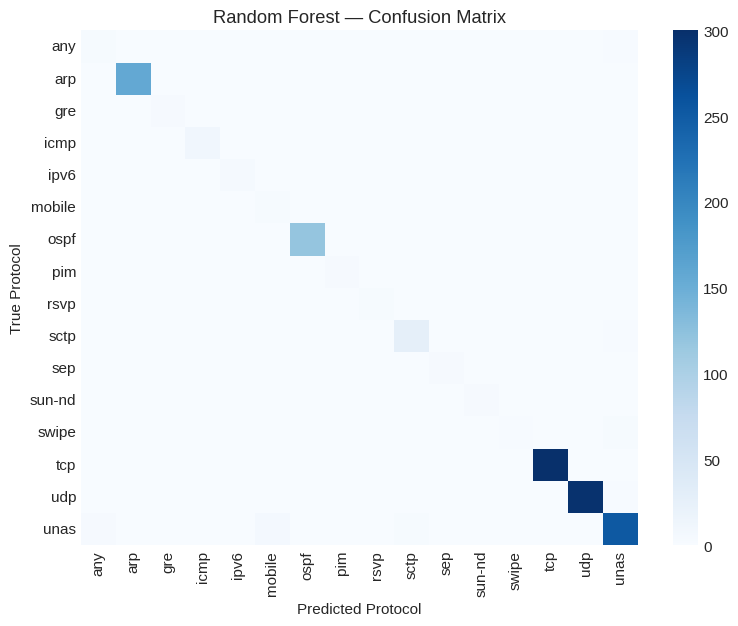

In [7]:
# =====================================================================
# Cell 6: Random Forest Protocol Classifier
# =====================================================================
print("[*] Training Random Forest Protocol Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    random_state=CONFIG['RANDOM_STATE'],
    n_jobs=-1
)

t0 = time.perf_counter()
rf_model.fit(X_train_dense, y_train)
rf_train_time = time.perf_counter() - t0

y_pred_rf, rf_metrics = evaluate_classifier(
    name='Random Forest',
    model=rf_model,
    X_eval=X_test_dense,
    y_eval=y_test,
    class_names=class_names,
    train_time=rf_train_time
)


## 7. Baseline Protocol Classifier 2: Linear SVM

**Linear Support Vector Machine (Linear SVM)** solves a convex optimization problem seeking maximum-margin hyperplanes separating protocol classes.
- **Hypothesis Space**: Linear decision boundaries in standardized feature space.
- **Scalability**: Implemented using `LinearSVC` with `dual='auto'` and `class_weight='balanced'`, which scales linearly with sample size $O(N \cdot D)$.
- **Distinction**: Designated explicitly as **Linear SVM** (not non-linear kernel SVM) to serve as a fast, convex baseline.


[*] Training Linear SVM Protocol Classifier...

 Linear SVM — Evaluation Report
Accuracy:        94.30%
Macro F1 Score:  0.4847
Weighted F1:     0.9423
Training Time:   5.39 s | Inference Time: 0.004 s


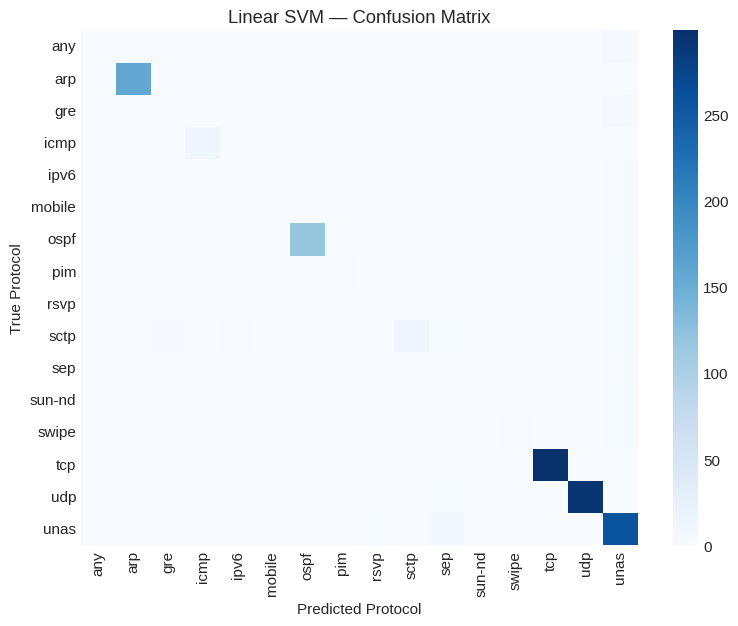

In [8]:
# =====================================================================
# Cell 7: Linear SVM Protocol Classifier
# =====================================================================
print("[*] Training Linear SVM Protocol Classifier...")
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=10_000,
    random_state=CONFIG['RANDOM_STATE'],
    dual='auto'
)

t0 = time.perf_counter()
svm_model.fit(X_train_dense, y_train)
svm_train_time = time.perf_counter() - t0

y_pred_svm, svm_metrics = evaluate_classifier(
    name='Linear SVM',
    model=svm_model,
    X_eval=X_test_dense,
    y_eval=y_test,
    class_names=class_names,
    train_time=svm_train_time
)


## 8. Deep Learning Architectures: 1D CNN & LSTM

### 8.1 1D Convolutional Neural Network (CNN)
The 1D CNN processes the tabular feature vector $\mathbf{x} \in \mathbb{R}^D$ shaped as $(1, D)$.
- **Architecture**:
  - Input: $(B, 1, D)$
  - Conv1D ($1 \to 32$, kernel=3, padding=1) $\to$ ReLU $\to$ MaxPool1D(2)
  - Conv1D ($32 \to 64$, kernel=3, padding=1) $\to$ ReLU $\to$ AdaptiveMaxPool1D(1)
  - Flatten $\to$ Dense(64, 64) $\to$ ReLU $\to$ Dropout(0.25) $\to$ Dense(64, $C$)
- **Differentiability**: Fully differentiable with respect to input $\mathbf{x}$, making it our primary **white-box target** and **surrogate** for black-box transfer attacks.

### 8.2 Long Short-Term Memory (LSTM)
The LSTM treats the feature vector as a sequence of length $D$ with scalar dimension $1$: $(B, D, 1)$.
- **Architecture**:
  - Input: $(B, D, 1)$
  - LSTM (input_size=1, hidden_size=64, batch_first=True)
  - Dropout(0.25) $\to$ Dense(64, $C$)
- **Important Methodological Note**: Tabular network flow records are aggregate statistical summaries, **not** a natural temporal time series of sequential packets. Processing ordered tabular features with an LSTM is an architectural benchmark configuration; its ordering does not represent real-world temporal causality.


In [9]:
# =====================================================================
# Cell 8: PyTorch Model Architectures & Training Pipeline
# =====================================================================
class CNNProtocolClassifier(nn.Module):
    """1D Convolutional Neural Network for Tabular Flow Vectors."""
    def __init__(self, in_features, num_classes, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(output_size=1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        feat = self.features(x)
        return self.head(feat)


class LSTMProtocolClassifier(nn.Module):
    """LSTM Sequence Classifier for Tabular Flow Vectors."""
    def __init__(self, in_features, num_classes, hidden_dim=64, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        _, (hidden, _) = self.lstm(x)
        return self.head(hidden[-1])


def train_pytorch_model(model, X_tr, y_tr, config, device, name="Model"):
    """
    General PyTorch training loop with Stratified Validation Split,
    Adam Optimizer, CrossEntropyLoss, and Early Stopping.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
    loss_fn = nn.CrossEntropyLoss()

    # Internal 90:10 train/validation split for early stopping
    X_t, X_val, y_t, y_val = train_test_split(
        X_tr, y_tr, test_size=0.10, random_state=config['RANDOM_STATE'], stratify=y_tr
    )

    train_ds = TensorDataset(torch.tensor(X_t, dtype=torch.float32), torch.tensor(y_t, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=config['BATCH_SIZE'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config['BATCH_SIZE'], shuffle=False)

    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    start_time = time.perf_counter()
    for epoch in range(config['EPOCHS']):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(yb)
            train_correct += (out.argmax(dim=1) == yb).sum().item()
            train_total += len(yb)

        epoch_loss = train_loss / train_total
        epoch_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = loss_fn(out, yb)

                val_loss += loss.item() * len(yb)
                val_correct += (out.argmax(dim=1) == yb).sum().item()
                val_total += len(yb)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['accuracy'].append(epoch_acc)
        history['val_accuracy'].append(epoch_val_acc)

        print(f"[{name}] Epoch {epoch+1:02d}/{config['EPOCHS']} — Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['PATIENCE']:
                print(f"[*] Early stopping triggered at epoch {epoch+1}.")
                break

    total_train_time = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    return model, history, total_train_time


def predict_pytorch(model, X_input, device, batch_size=256):
    """Generates predictions from a PyTorch model on a numpy array."""
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(0, len(X_input), batch_size):
            xb = torch.tensor(X_input[i:i+batch_size], dtype=torch.float32, device=device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            predictions.append(preds)
    return np.concatenate(predictions)


def plot_learning_curves(history, title="Learning Curves"):
    """Plots training and validation loss and accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history['loss'], label='Train Loss', color='royalblue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='crimson', linestyle='--')
    axes[0].set_title(f"{title} — Cross-Entropy Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history['accuracy'], label='Train Accuracy', color='royalblue')
    axes[1].plot(history['val_accuracy'], label='Val Accuracy', color='crimson', linestyle='--')
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


[*] Training 1D CNN Protocol Classifier...


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[1D CNN] Epoch 01/15 — Loss: 2.2449 | Acc: 25.34% | Val Loss: 1.7495 | Val Acc: 38.41%
[1D CNN] Epoch 02/15 — Loss: 1.5509 | Acc: 48.96% | Val Loss: 1.2664 | Val Acc: 60.16%
[1D CNN] Epoch 03/15 — Loss: 1.0902 | Acc: 69.10% | Val Loss: 0.9223 | Val Acc: 79.07%
[1D CNN] Epoch 04/15 — Loss: 0.8186 | Acc: 81.40% | Val Loss: 0.7478 | Val Acc: 81.50%
[1D CNN] Epoch 05/15 — Loss: 0.6695 | Acc: 84.93% | Val Loss: 0.5892 | Val Acc: 88.01%
[1D CNN] Epoch 06/15 — Loss: 0.5529 | Acc: 87.60% | Val Loss: 0.5081 | Val Acc: 89.02%
[1D CNN] Epoch 07/15 — Loss: 0.4916 | Acc: 89.32% | Val Loss: 0.4497 | Val Acc: 89.84%
[1D CNN] Epoch 08/15 — Loss: 0.4445 | Acc: 90.16% | Val Loss: 0.4217 | Val Acc: 90.85%
[1D CNN] Epoch 09/15 — Loss: 0.4095 | Acc: 91.13% | Val Loss: 0.3913 | Val Acc: 90.85%
[1D CNN] Epoch 10/15 — Loss: 0.3803 | Acc: 91.45% | Val Loss: 0.3873 | Val Acc: 90.85%
[1D CNN] Epoch 11/15 — Loss: 0.3755 | Acc: 91.76% | Val Loss: 0.3594 | Val Acc: 91.26%
[1D CNN] Epoch 12/15 — Loss: 0.3585 | Acc: 

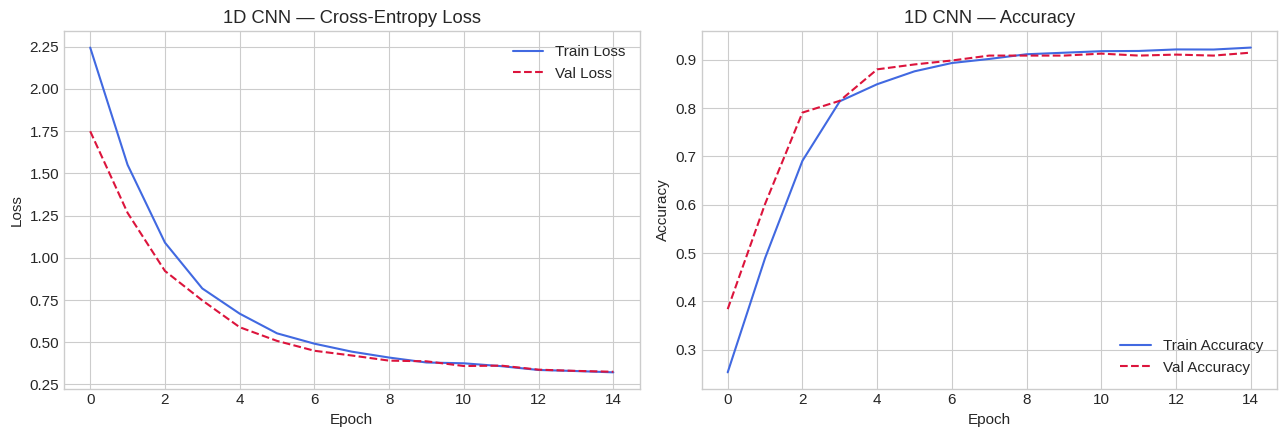


 1D CNN — Evaluation Report
Accuracy:        92.18%
Macro F1 Score:  0.3136
Weighted F1:     0.8950
Training Time:   2.87 s | Inference Time: 0.018 s


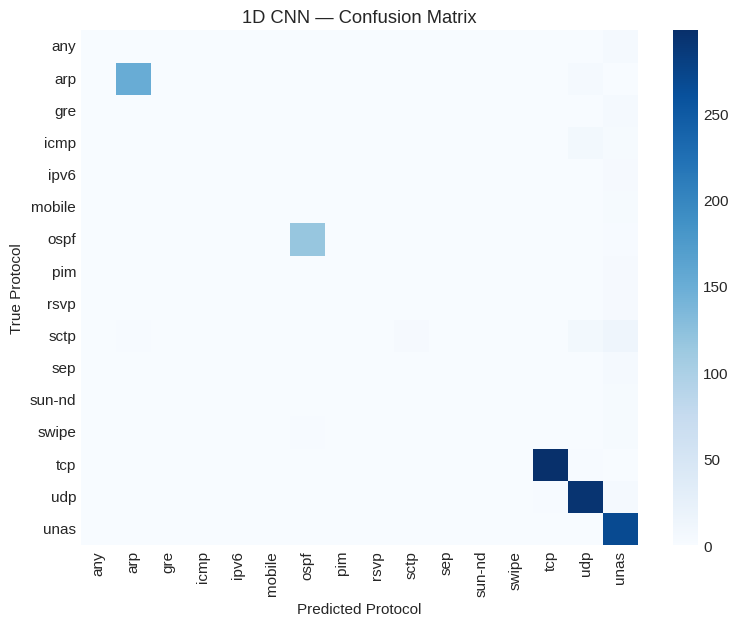

In [10]:
# =====================================================================
# Cell 9: Train & Evaluate 1D CNN Protocol Classifier
# =====================================================================
print("[*] Training 1D CNN Protocol Classifier...")
cnn_model = CNNProtocolClassifier(
    in_features=num_features,
    num_classes=num_classes,
    dropout=CONFIG['DROPOUT_RATE']
)

cnn_model, cnn_history, cnn_train_time = train_pytorch_model(
    model=cnn_model,
    X_tr=X_train_dense,
    y_tr=y_train,
    config=CONFIG,
    device=DEVICE,
    name="1D CNN"
)

plot_learning_curves(cnn_history, title="1D CNN")

y_pred_cnn, cnn_metrics = evaluate_classifier(
    name='1D CNN',
    model=cnn_model,
    X_eval=X_test_dense,
    y_eval=y_test,
    class_names=class_names,
    train_time=cnn_train_time,
    predict_fn=lambda x: predict_pytorch(cnn_model, x, DEVICE)
)


[*] Training LSTM Protocol Classifier...
[LSTM] Epoch 01/15 — Loss: 2.4179 | Acc: 24.19% | Val Loss: 1.8568 | Val Acc: 24.39%
[LSTM] Epoch 02/15 — Loss: 1.8699 | Acc: 23.62% | Val Loss: 1.8437 | Val Acc: 24.39%
[LSTM] Epoch 03/15 — Loss: 1.8587 | Acc: 24.34% | Val Loss: 1.8427 | Val Acc: 24.39%
[LSTM] Epoch 04/15 — Loss: 1.8571 | Acc: 24.46% | Val Loss: 1.8435 | Val Acc: 24.39%
[LSTM] Epoch 05/15 — Loss: 1.8506 | Acc: 24.07% | Val Loss: 1.8420 | Val Acc: 25.81%
[LSTM] Epoch 06/15 — Loss: 1.8528 | Acc: 23.67% | Val Loss: 1.8422 | Val Acc: 24.39%
[LSTM] Epoch 07/15 — Loss: 1.8518 | Acc: 23.94% | Val Loss: 1.8440 | Val Acc: 24.39%
[LSTM] Epoch 08/15 — Loss: 1.8438 | Acc: 23.87% | Val Loss: 1.8415 | Val Acc: 24.39%
[LSTM] Epoch 09/15 — Loss: 1.8474 | Acc: 24.34% | Val Loss: 1.8430 | Val Acc: 24.39%
[LSTM] Epoch 10/15 — Loss: 1.8450 | Acc: 24.21% | Val Loss: 1.8406 | Val Acc: 24.39%
[LSTM] Epoch 11/15 — Loss: 1.8441 | Acc: 25.32% | Val Loss: 1.8402 | Val Acc: 24.39%
[LSTM] Epoch 12/15 — Los

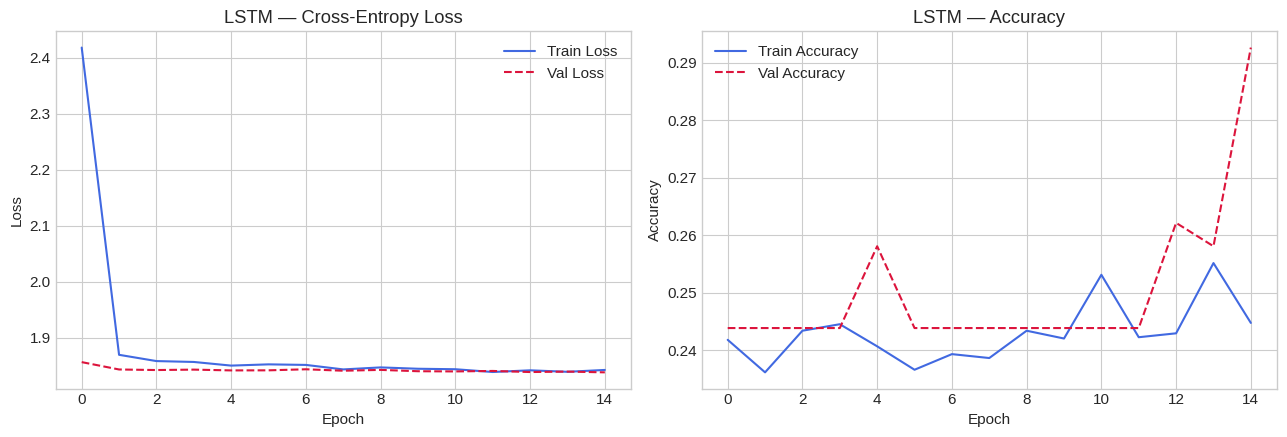


 LSTM — Evaluation Report
Accuracy:        28.66%
Macro F1 Score:  0.0439
Weighted F1:     0.1715
Training Time:   2.05 s | Inference Time: 0.009 s


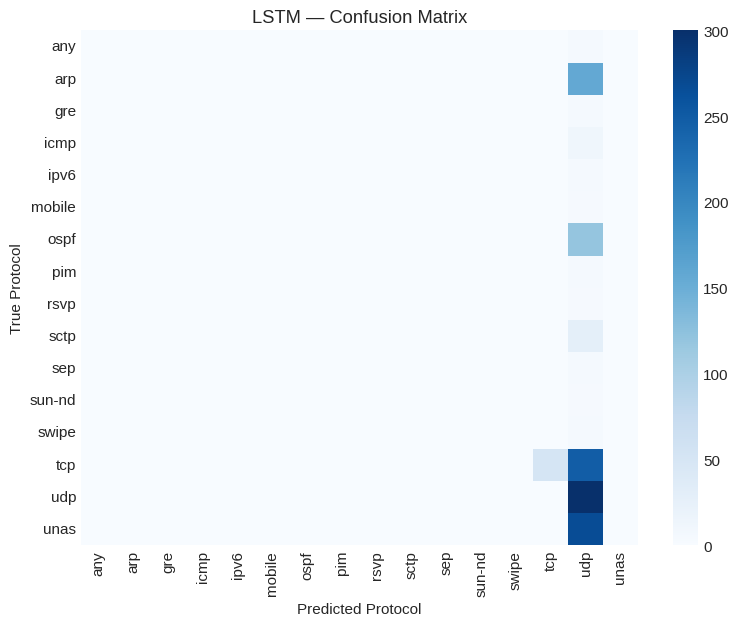

In [11]:
# =====================================================================
# Cell 10: Train & Evaluate LSTM Protocol Classifier
# =====================================================================
print("[*] Training LSTM Protocol Classifier...")
lstm_model = LSTMProtocolClassifier(
    in_features=num_features,
    num_classes=num_classes,
    hidden_dim=64,
    dropout=CONFIG['DROPOUT_RATE']
)

lstm_model, lstm_history, lstm_train_time = train_pytorch_model(
    model=lstm_model,
    X_tr=X_train_dense,
    y_tr=y_train,
    config=CONFIG,
    device=DEVICE,
    name="LSTM"
)

plot_learning_curves(lstm_history, title="LSTM")

y_pred_lstm, lstm_metrics = evaluate_classifier(
    name='LSTM',
    model=lstm_model,
    X_eval=X_test_dense,
    y_eval=y_test,
    class_names=class_names,
    train_time=lstm_train_time,
    predict_fn=lambda x: predict_pytorch(lstm_model, x, DEVICE)
)


## 9. TABLE 1: Clean Baseline Performance Comparison

Below is the programmatically generated comparison table summarizing the clean classification performance, computational cost, and class-weighted metrics for all four architectures:
- **Random Forest**
- **Linear SVM**
- **1D CNN**
- **LSTM**



 TABLE 1: Clean Protocol Classification Performance Comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Inference Time (s)
0,Random Forest,97.39%,0.8581,0.8549,0.8402,0.9752,0.86,0.034
1,Linear SVM,94.30%,0.5000,0.4773,0.4847,0.9423,5.39,0.004
2,1D CNN,92.18%,0.3536,0.3158,0.3136,0.8950,2.87,0.018
3,LSTM,28.66%,0.0784,0.0733,0.0439,0.1715,2.05,0.009


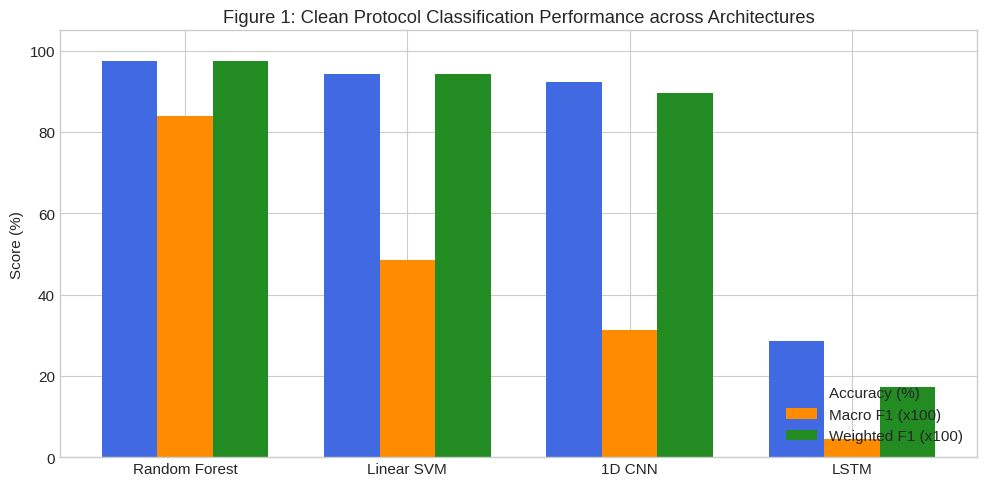

In [12]:
# =====================================================================
# Cell 11: Programmatic TABLE 1 Generation & Model Comparison
# =====================================================================
table_1_df = pd.DataFrame.from_dict(baseline_results, orient='index')
table_1_df = table_1_df[[
    'Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1',
    'Weighted F1', 'Training Time (s)', 'Inference Time (s)'
]].reset_index(drop=True)

print("\n" + "="*80)
print(" TABLE 1: Clean Protocol Classification Performance Comparison")
print("="*80)
display_table_1 = table_1_df.copy()
display_table_1['Accuracy'] = display_table_1['Accuracy'].apply(lambda v: f"{v:.2f}%")
display_table_1['Macro Precision'] = display_table_1['Macro Precision'].apply(lambda v: f"{v:.4f}")
display_table_1['Macro Recall'] = display_table_1['Macro Recall'].apply(lambda v: f"{v:.4f}")
display_table_1['Macro F1'] = display_table_1['Macro F1'].apply(lambda v: f"{v:.4f}")
display_table_1['Weighted F1'] = display_table_1['Weighted F1'].apply(lambda v: f"{v:.4f}")
display(display_table_1)

# Visual Comparison Plot
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(table_1_df))
width = 0.25

rects1 = ax.bar(x_pos - width, table_1_df['Accuracy'], width, label='Accuracy (%)', color='royalblue')
rects2 = ax.bar(x_pos, table_1_df['Macro F1'] * 100, width, label='Macro F1 (x100)', color='darkorange')
rects3 = ax.bar(x_pos + width, table_1_df['Weighted F1'] * 100, width, label='Weighted F1 (x100)', color='forestgreen')

ax.set_title('Figure 1: Clean Protocol Classification Performance across Architectures')
ax.set_xticks(x_pos)
ax.set_xticklabels(table_1_df['Model'])
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 10. Adversarial Threat Model & Mathematical Formulation

### 10.1 Threat Model Specification
1. **Adversary's Objective**: Inference-time evasion attack. The adversary seeks to perturb test flow features to cause protocol misclassification:
   $$f(\mathbf{x}_{adv}) \ne y_{true}$$
2. **Attack Space**: Standardized feature space $\mathbb{R}^D$.
3. **Perturbation Constraint ($L_\infty$-bounded)**:
   $$\|\mathbf{x}_{adv} - \mathbf{x}\|_\infty \le \epsilon$$
   The perturbation is bounded by $\epsilon$ across continuous feature dimensions.
4. **Feature Invariance Masking**:
   $$\mathbf{x}_{adv} = \mathbf{x} + \mathbf{\delta} \odot \mathbf{m}$$
   where $\mathbf{m} \in \{0, 1\}^D$ is the continuous feature mask ($1$ for continuous flow features, $0$ for one-hot indicators). Categorical indicators cannot be continuously shifted.
5. **Feature Space vs. Problem Space**:
   - The attacks perturb numerical flow metrics (e.g., packet counts, byte statistics).
   - We explicitly recognize that feature-space perturbations do not immediately yield executable PCAP network packets without inverse packet synthesis.
6. **Adversary Knowledge**:
   - **White-Box**: Complete access to surrogate model weights $\mathbf{\theta}$ and gradients $\nabla_\mathbf{x} \mathcal{L}$ (1D CNN).
   - **Black-Box (Transfer)**: Zero access to target model parameters, architecture, or gradients (Random Forest, Linear SVM). The adversary queries the target with adversarial examples generated from the surrogate CNN.


## 11. White-Box Gradient Attacks: True FGSM & True PGD

### 11.1 Fast Gradient Sign Method (FGSM)
Calculates the gradient of the loss $\mathcal{L}$ with respect to the input $\mathbf{x}$ in a single backward pass:
$$\mathbf{x}_{adv} = \mathbf{x} + \epsilon \cdot \text{sign}\left(\nabla_\mathbf{x} \mathcal{L}(f_\theta(\mathbf{x}), y)\right) \odot \mathbf{m}$$

### 11.2 Projected Gradient Descent (PGD)
Iterative multi-step attack with projection onto the $L_\infty$ ball $\mathcal{B}_\epsilon(\mathbf{x})$:
$$\mathbf{x}^{(0)} = \mathbf{x} + \mathcal{U}(-\epsilon, \epsilon) \odot \mathbf{m}$$
$$\mathbf{x}^{(t+1)} = \Pi_{\mathbf{x} + \mathcal{S}_\epsilon} \left( \mathbf{x}^{(t)} + \alpha \cdot \text{sign}\left(\nabla_{\mathbf{x}^{(t)}} \mathcal{L}(f_\theta(\mathbf{x}^{(t)}), y)\right) \odot \mathbf{m} \right)$$

### 11.3 Attack Success Rate (ASR)
The Attack Success Rate is strictly defined over samples that were **initially correctly classified** on clean data:
$$\text{Initially Correct} = \{i \mid \hat{y}_i^{clean} = y_i\}$$
$$\text{Successful Attack} = \{i \in \text{Initially Correct} \mid \hat{y}_i^{adv} \ne y_i\}$$
$$\text{ASR} = \frac{|\text{Successful Attack}|}{|\text{Initially Correct}|}$$
If $|\text{Initially Correct}| = 0$, ASR is safely set to $0.0$.


In [13]:
# =====================================================================
# Cell 12: True FGSM, True PGD, ASR & Perturbation Statistics
# =====================================================================
def compute_asr(y_clean_pred, y_adv_pred, y_true):
    """
    Calculates Attack Success Rate (ASR) strictly on initially correctly classified samples.
    """
    initially_correct = (y_clean_pred == y_true)
    total_correct = int(initially_correct.sum())
    if total_correct == 0:
        return 0.0
    successful_attack = initially_correct & (y_adv_pred != y_true)
    return float(successful_attack.sum()) / float(total_correct) * 100.0


def compute_perturbation_norms(X_clean, X_adv):
    """Computes mean L_inf and mean L_2 perturbation magnitudes."""
    diff = X_adv - X_clean
    linf = np.max(np.abs(diff), axis=1).mean()
    l2 = np.linalg.norm(diff, axis=1).mean()
    return linf, l2


def generate_true_fgsm(model, X, y, epsilon, feature_mask, device, batch_size=256):
    """
    Generates REAL gradient-based FGSM adversarial perturbations.
    Only continuous features (mask=1.0) receive perturbations.
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    mask_tensor = torch.tensor(feature_mask, dtype=torch.float32, device=device).unsqueeze(0)

    X_adv_batches = []
    for i in range(0, len(X), batch_size):
        xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device, requires_grad=True)
        yb = torch.tensor(y[i:i+batch_size], dtype=torch.long, device=device)

        out = model(xb)
        loss = loss_fn(out, yb)
        model.zero_grad()
        loss.backward()

        grad = xb.grad.data
        masked_grad = grad * mask_tensor
        xb_adv = xb.detach() + epsilon * masked_grad.sign()
        X_adv_batches.append(xb_adv.cpu().numpy())

    return np.concatenate(X_adv_batches, axis=0)


def generate_true_pgd(model, X, y, epsilon, alpha, steps, feature_mask, device, random_start=True, batch_size=256):
    """
    Generates REAL Projected Gradient Descent (PGD) multi-step adversarial perturbations.
    Only continuous features (mask=1.0) receive perturbations.
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    mask_tensor = torch.tensor(feature_mask, dtype=torch.float32, device=device).unsqueeze(0)

    X_adv_batches = []
    for i in range(0, len(X), batch_size):
        x_orig = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
        yb = torch.tensor(y[i:i+batch_size], dtype=torch.long, device=device)

        x_adv = x_orig.clone().detach()
        if random_start:
            noise = torch.empty_like(x_adv).uniform_(-epsilon, epsilon) * mask_tensor
            x_adv = x_adv + noise

        for step in range(steps):
            x_adv.requires_grad = True
            out = model(x_adv)
            loss = loss_fn(out, yb)
            model.zero_grad()
            loss.backward()

            grad = x_adv.grad.data
            masked_grad = grad * mask_tensor
            x_adv = x_adv.detach() + alpha * masked_grad.sign()

            eta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon) * mask_tensor
            x_adv = (x_orig + eta).detach()

        X_adv_batches.append(x_adv.cpu().numpy())

    return np.concatenate(X_adv_batches, axis=0)


## 12. White-Box Attack Evaluation (Target: 1D CNN)

We evaluate the differentiable **1D CNN** under:
1. **FGSM** across multiple perturbation budgets: $\epsilon \in [0.01, 0.05, 0.10, 0.20]$.
2. **PGD** with $\epsilon = 0.10$, step size $\alpha = 0.02$, and $K = 10$ iterations.


In [14]:
# =====================================================================
# Cell 13: White-Box Attack Execution on 1D CNN
# =====================================================================
attack_results = []

print("[*] Generating and Evaluating White-Box FGSM Attacks on 1D CNN...")
for eps in CONFIG['FGSM_EPSILONS']:
    X_test_fgsm = generate_true_fgsm(
        model=cnn_model,
        X=X_test_dense,
        y=y_test,
        epsilon=eps,
        feature_mask=continuous_feature_mask,
        device=DEVICE
    )

    y_pred_fgsm = predict_pytorch(cnn_model, X_test_fgsm, DEVICE)
    acc_fgsm = accuracy_score(y_test, y_pred_fgsm) * 100.0
    acc_drop = cnn_metrics['Accuracy'] - acc_fgsm
    asr_fgsm = compute_asr(y_pred_cnn, y_pred_fgsm, y_test)
    linf, l2 = compute_perturbation_norms(X_test_dense, X_test_fgsm)

    attack_results.append({
        'Target Model': '1D CNN',
        'Attack': 'FGSM',
        'Knowledge': 'White-Box',
        'Epsilon': eps,
        'Perturbed Acc (%)': acc_fgsm,
        'Accuracy Drop (%)': acc_drop,
        'ASR (%)': asr_fgsm,
        'Mean L_inf': linf,
        'Mean L_2': l2,
        'X_adv': X_test_fgsm
    })
    print(f"    FGSM (eps={eps:.2f}) -> Acc: {acc_fgsm:.2f}% | Drop: {acc_drop:.2f}% | ASR: {asr_fgsm:.2f}%")

print("\n[*] Generating and Evaluating White-Box PGD Attack on 1D CNN...")
X_test_pgd = generate_true_pgd(
    model=cnn_model,
    X=X_test_dense,
    y=y_test,
    epsilon=CONFIG['PGD_EPSILON'],
    alpha=CONFIG['PGD_ALPHA'],
    steps=CONFIG['PGD_STEPS'],
    feature_mask=continuous_feature_mask,
    device=DEVICE
)

y_pred_pgd = predict_pytorch(cnn_model, X_test_pgd, DEVICE)
acc_pgd = accuracy_score(y_test, y_pred_pgd) * 100.0
acc_drop_pgd = cnn_metrics['Accuracy'] - acc_pgd
asr_pgd = compute_asr(y_pred_cnn, y_pred_pgd, y_test)
linf_pgd, l2_pgd = compute_perturbation_norms(X_test_dense, X_test_pgd)

attack_results.append({
    'Target Model': '1D CNN',
    'Attack': f"PGD (steps={CONFIG['PGD_STEPS']})",
    'Knowledge': 'White-Box',
    'Epsilon': CONFIG['PGD_EPSILON'],
    'Perturbed Acc (%)': acc_pgd,
    'Accuracy Drop (%)': acc_drop_pgd,
    'ASR (%)': asr_pgd,
    'Mean L_inf': linf_pgd,
    'Mean L_2': l2_pgd,
    'X_adv': X_test_pgd
})
print(f"    PGD (eps={CONFIG['PGD_EPSILON']:.2f})  -> Acc: {acc_pgd:.2f}% | Drop: {acc_drop_pgd:.2f}% | ASR: {asr_pgd:.2f}%")


[*] Generating and Evaluating White-Box FGSM Attacks on 1D CNN...
    FGSM (eps=0.01) -> Acc: 92.18% | Drop: 0.00% | ASR: 0.00%
    FGSM (eps=0.05) -> Acc: 91.29% | Drop: 0.90% | ASR: 0.97%
    FGSM (eps=0.10) -> Acc: 84.53% | Drop: 7.65% | ASR: 8.30%
    FGSM (eps=0.20) -> Acc: 55.13% | Drop: 37.05% | ASR: 40.19%

[*] Generating and Evaluating White-Box PGD Attack on 1D CNN...


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

    PGD (eps=0.10)  -> Acc: 81.03% | Drop: 11.16% | ASR: 12.10%


## 13. Transfer-Based Black-Box Attack

In real-world network security deployments, internal model parameters and gradients of firewall or intrusion detection classifiers are typically inaccessible to external adversaries.

### Threat Model & Methodology:
- **Surrogate Model**: Differentiable **1D CNN** trained on the same feature distribution.
- **Target Models**: Non-differentiable **Random Forest** and **Linear SVM**.
- **Attack Procedure**:
  - The attacker generates adversarial examples using the CNN surrogate.
  - Those examples are then evaluated against Random Forest and Linear SVM.
  - Gradients and internal parameters of the target models are not used to generate the attack.
- **Evaluation Objective**: Measure cross-model evasion transferability by comparing clean accuracy against adversarial accuracy, computing accuracy degradation and transfer ASR.


In [15]:
# =====================================================================
# Cell 14: Black-Box Transfer Attack Execution (Surrogate CNN -> RF & SVM)
# =====================================================================
X_adv_fgsm_01 = [res['X_adv'] for res in attack_results if res['Attack'] == 'FGSM' and res['Epsilon'] == 0.10][0]
X_adv_pgd_01 = X_test_pgd

# 1. Transfer Attack against Random Forest
print("[*] Evaluating Transfer Attack against Random Forest...")
y_rf_fgsm = rf_model.predict(X_adv_fgsm_01)
acc_rf_fgsm = accuracy_score(y_test, y_rf_fgsm) * 100.0
asr_rf_fgsm = compute_asr(y_pred_rf, y_rf_fgsm, y_test)

y_rf_pgd = rf_model.predict(X_adv_pgd_01)
acc_rf_pgd = accuracy_score(y_test, y_rf_pgd) * 100.0
asr_rf_pgd = compute_asr(y_pred_rf, y_rf_pgd, y_test)

linf_t, l2_t = compute_perturbation_norms(X_test_dense, X_adv_fgsm_01)
attack_results.append({
    'Target Model': 'Random Forest',
    'Attack': 'FGSM (Surrogate CNN)',
    'Knowledge': 'Black-Box (Transfer)',
    'Epsilon': 0.10,
    'Perturbed Acc (%)': acc_rf_fgsm,
    'Accuracy Drop (%)': rf_metrics['Accuracy'] - acc_rf_fgsm,
    'ASR (%)': asr_rf_fgsm,
    'Mean L_inf': linf_t,
    'Mean L_2': l2_t,
    'X_adv': None
})

linf_tp, l2_tp = compute_perturbation_norms(X_test_dense, X_adv_pgd_01)
attack_results.append({
    'Target Model': 'Random Forest',
    'Attack': 'PGD (Surrogate CNN)',
    'Knowledge': 'Black-Box (Transfer)',
    'Epsilon': 0.10,
    'Perturbed Acc (%)': acc_rf_pgd,
    'Accuracy Drop (%)': rf_metrics['Accuracy'] - acc_rf_pgd,
    'ASR (%)': asr_rf_pgd,
    'Mean L_inf': linf_tp,
    'Mean L_2': l2_tp,
    'X_adv': None
})
print(f"    RF Transfer FGSM -> Acc: {acc_rf_fgsm:.2f}% | Drop: {rf_metrics['Accuracy'] - acc_rf_fgsm:.2f}% | ASR: {asr_rf_fgsm:.2f}%")
print(f"    RF Transfer PGD  -> Acc: {acc_rf_pgd:.2f}% | Drop: {rf_metrics['Accuracy'] - acc_rf_pgd:.2f}% | ASR: {asr_rf_pgd:.2f}%")

# 2. Transfer Attack against Linear SVM
print("\n[*] Evaluating Transfer Attack against Linear SVM...")
y_svm_fgsm = svm_model.predict(X_adv_fgsm_01)
acc_svm_fgsm = accuracy_score(y_test, y_svm_fgsm) * 100.0
asr_svm_fgsm = compute_asr(y_pred_svm, y_svm_fgsm, y_test)

y_svm_pgd = svm_model.predict(X_adv_pgd_01)
acc_svm_pgd = accuracy_score(y_test, y_svm_pgd) * 100.0
asr_svm_pgd = compute_asr(y_pred_svm, y_svm_pgd, y_test)

attack_results.append({
    'Target Model': 'Linear SVM',
    'Attack': 'FGSM (Surrogate CNN)',
    'Knowledge': 'Black-Box (Transfer)',
    'Epsilon': 0.10,
    'Perturbed Acc (%)': acc_svm_fgsm,
    'Accuracy Drop (%)': svm_metrics['Accuracy'] - acc_svm_fgsm,
    'ASR (%)': asr_svm_fgsm,
    'Mean L_inf': linf_t,
    'Mean L_2': l2_t,
    'X_adv': None
})

attack_results.append({
    'Target Model': 'Linear SVM',
    'Attack': 'PGD (Surrogate CNN)',
    'Knowledge': 'Black-Box (Transfer)',
    'Epsilon': 0.10,
    'Perturbed Acc (%)': acc_svm_pgd,
    'Accuracy Drop (%)': svm_metrics['Accuracy'] - acc_svm_pgd,
    'ASR (%)': asr_svm_pgd,
    'Mean L_inf': linf_tp,
    'Mean L_2': l2_tp,
    'X_adv': None
})
print(f"    SVM Transfer FGSM -> Acc: {acc_svm_fgsm:.2f}% | Drop: {svm_metrics['Accuracy'] - acc_svm_fgsm:.2f}% | ASR: {asr_svm_fgsm:.2f}%")
print(f"    SVM Transfer PGD  -> Acc: {acc_svm_pgd:.2f}% | Drop: {svm_metrics['Accuracy'] - acc_svm_pgd:.2f}% | ASR: {asr_svm_pgd:.2f}%")


[*] Evaluating Transfer Attack against Random Forest...
    RF Transfer FGSM -> Acc: 34.45% | Drop: 62.95% | ASR: 64.63%
    RF Transfer PGD  -> Acc: 41.45% | Drop: 55.94% | ASR: 57.78%

[*] Evaluating Transfer Attack against Linear SVM...
    SVM Transfer FGSM -> Acc: 88.27% | Drop: 6.03% | ASR: 6.74%
    SVM Transfer PGD  -> Acc: 86.32% | Drop: 7.98% | ASR: 8.55%


## 14. TABLE 2: Adversarial Attack Results (White-Box & Black-Box)

The table below summarizes the evasion attack outcomes across both white-box and transfer black-box conditions:
- Target Model & Attack Formulation
- Threat Model (White-Box vs. Black-Box Transfer)
- Perturbation Budget $\epsilon$
- Perturbed Accuracy & Accuracy Drop
- Attack Success Rate (ASR)
- Average $L_\infty$ and $L_2$ Perturbation Norms



 TABLE 2: Adversarial Evasion Attack Performance (White-Box & Black-Box)


,Target Model,Attack,Knowledge,Epsilon,Perturbed Acc (%),Accuracy Drop (%),ASR (%),Mean L_inf,Mean L_2
0,1D CNN,FGSM,White-Box,0.01,92.18%,0.00%,0.00%,0.0100,0.0610
1,1D CNN,FGSM,White-Box,0.05,91.29%,0.90%,0.97%,0.0500,0.3049
2,1D CNN,FGSM,White-Box,0.10,84.53%,7.65%,8.30%,0.1000,0.6098
3,1D CNN,FGSM,White-Box,0.20,55.13%,37.05%,40.19%,0.2000,1.2196
4,1D CNN,PGD (steps=10),White-Box,0.10,81.03%,11.16%,12.10%,0.1000,0.5672
5,Random Forest,FGSM (Surrogate CNN),Black-Box (Transfer),0.10,34.45%,62.95%,64.63%,0.1000,0.6098
6,Random Forest,PGD (Surrogate CNN),Black-Box (Transfer),0.10,41.45%,55.94%,57.78%,0.1000,0.5672
7,Linear SVM,FGSM (Surrogate CNN),Black-Box (Transfer),0.10,88.27%,6.03%,6.74%,0.1000,0.6098
8,Linear SVM,PGD (Surrogate CNN),Black-Box (Transfer),0.10,86.32%,7.98%,8.55%,0.1000,0.5672


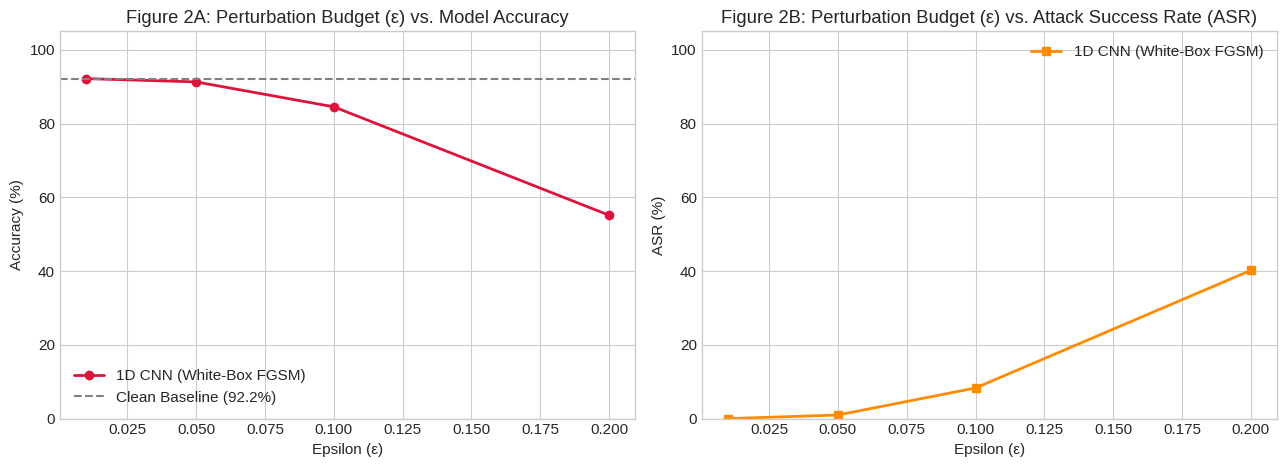

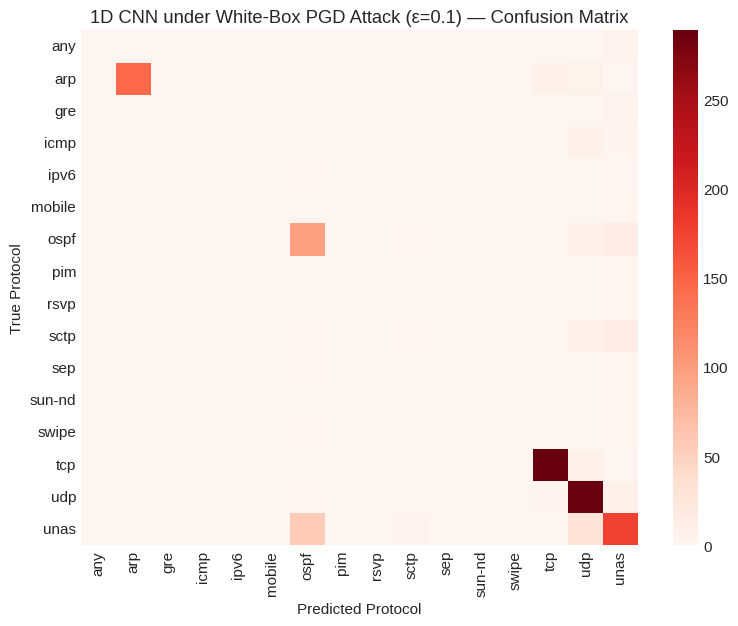

In [16]:
# =====================================================================
# Cell 15: Programmatic TABLE 2 Generation & Attack Robustness Curves
# =====================================================================
table_2_df = pd.DataFrame(attack_results).drop(columns=['X_adv'])
print("\n" + "="*95)
print(" TABLE 2: Adversarial Evasion Attack Performance (White-Box & Black-Box)")
print("="*95)
display_table_2 = table_2_df.copy()
display_table_2['Perturbed Acc (%)'] = display_table_2['Perturbed Acc (%)'].apply(lambda v: f"{v:.2f}%")
display_table_2['Accuracy Drop (%)'] = display_table_2['Accuracy Drop (%)'].apply(lambda v: f"{v:.2f}%")
display_table_2['ASR (%)'] = display_table_2['ASR (%)'].apply(lambda v: f"{v:.2f}%")
display_table_2['Mean L_inf'] = display_table_2['Mean L_inf'].apply(lambda v: f"{v:.4f}")
display_table_2['Mean L_2'] = display_table_2['Mean L_2'].apply(lambda v: f"{v:.4f}")
display(display_table_2)

# Figure 2: Attack Strength (Epsilon) vs. Accuracy and ASR on 1D CNN
fgsm_cnn_rows = [r for r in attack_results if r['Target Model'] == '1D CNN' and r['Attack'] == 'FGSM']
eps_vals = [r['Epsilon'] for r in fgsm_cnn_rows]
acc_vals = [r['Perturbed Acc (%)'] for r in fgsm_cnn_rows]
asr_vals = [r['ASR (%)'] for r in fgsm_cnn_rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(eps_vals, acc_vals, marker='o', linewidth=2, color='crimson', label='1D CNN (White-Box FGSM)')
axes[0].axhline(cnn_metrics['Accuracy'], color='gray', linestyle='--', label=f"Clean Baseline ({cnn_metrics['Accuracy']:.1f}%)")
axes[0].set_title('Figure 2A: Perturbation Budget (ε) vs. Model Accuracy')
axes[0].set_xlabel('Epsilon (ε)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].legend()

axes[1].plot(eps_vals, asr_vals, marker='s', linewidth=2, color='darkorange', label='1D CNN (White-Box FGSM)')
axes[1].set_title('Figure 2B: Perturbation Budget (ε) vs. Attack Success Rate (ASR)')
axes[1].set_xlabel('Epsilon (ε)')
axes[1].set_ylabel('ASR (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
plt.tight_layout()
plt.show()

# Figure 3: Confusion Matrix under PGD Attack
cm_pgd = confusion_matrix(y_test, y_pred_pgd)
plt.figure(figsize=(max(8, len(class_names)*0.5), max(6, len(class_names)*0.4)))
sns.heatmap(cm_pgd, annot=(len(class_names) <= 15), fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"1D CNN under White-Box PGD Attack (ε={CONFIG['PGD_EPSILON']}) — Confusion Matrix")
plt.xlabel("Predicted Protocol")
plt.ylabel("True Protocol")
plt.tight_layout()
plt.show()


## 15. Defense 1: Adversarial Training

**Adversarial Training** (Goodfellow et al., 2014; Madry et al., 2018) is the standard defense against evasion attacks. It formulates training as a min-max optimization problem:
$$\min_\theta \mathbb{E}_{(\mathbf{x}, y)} \left[ \frac{1}{2} \mathcal{L}(f_\theta(\mathbf{x}), y) + \frac{1}{2} \mathcal{L}(f_\theta(\mathbf{x}_{adv}), y) \right]$$

### Methodology:
1. During each training mini-batch, compute real gradient-based FGSM adversarial samples on the fly:
   $$\mathbf{x}_{adv} = \mathbf{x} + \epsilon_{adv} \cdot \text{sign}\left(\nabla_\mathbf{x} \mathcal{L}(f_\theta(\mathbf{x}), y)\right) \odot \mathbf{m}$$
2. Concatenate clean batch $[\mathbf{x}, y]$ with adversarial batch $[\mathbf{x}_{adv}, y]$.
3. Optimize model weights to simultaneously classify both clean and adversarially perturbed flows.
4. Evaluate the defended model against clean inputs, white-box FGSM, and white-box PGD.


In [17]:
# =====================================================================
# Cell 16: Adversarial Training Implementation & Evaluation
# =====================================================================
def train_adversarial_cnn(X_tr, y_tr, feature_mask, config, device):
    """
    Retrains a robust 1D CNN using genuine on-the-fly FGSM adversarial training.
    """
    model = CNNProtocolClassifier(
        in_features=X_tr.shape[1],
        num_classes=num_classes,
        dropout=config['DROPOUT_RATE']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
    loss_fn = nn.CrossEntropyLoss()
    mask_tensor = torch.tensor(feature_mask, dtype=torch.float32, device=device).unsqueeze(0)

    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=config['BATCH_SIZE'], shuffle=True)

    print(f"[*] Starting Adversarial Training (eps={config['ADV_TRAIN_EPSILON']}, epochs={config['ADV_TRAIN_EPOCHS']})...")
    start_time = time.perf_counter()

    for epoch in range(config['ADV_TRAIN_EPOCHS']):
        model.train()
        total_loss, total_correct, total_count = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # 1. Generate real FGSM adversarial perturbations on current batch
            xb_adv = xb.clone().detach().requires_grad_(True)
            out_for_grad = model(xb_adv)
            loss_grad = loss_fn(out_for_grad, yb)
            model.zero_grad()
            loss_grad.backward()

            grad = xb_adv.grad.data * mask_tensor
            xb_adv = (xb.detach() + config['ADV_TRAIN_EPSILON'] * grad.sign()).detach()

            # 2. Combine clean and adversarial batches (50% clean, 50% adversarial)
            xb_combined = torch.cat([xb, xb_adv], dim=0)
            yb_combined = torch.cat([yb, yb], dim=0)

            # 3. Model parameter update
            optimizer.zero_grad()
            out_combined = model(xb_combined)
            loss = loss_fn(out_combined, yb_combined)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(yb_combined)
            total_correct += (out_combined.argmax(dim=1) == yb_combined).sum().item()
            total_count += len(yb_combined)

        epoch_loss = total_loss / total_count
        epoch_acc = total_correct / total_count
        print(f"[Adv-Train] Epoch {epoch+1:02d}/{config['ADV_TRAIN_EPOCHS']} — Combined Loss: {epoch_loss:.4f} | Combined Acc: {epoch_acc*100:.2f}%")

    adv_train_time = time.perf_counter() - start_time
    return model, adv_train_time

# Train Defended CNN
cnn_defended, adv_train_duration = train_adversarial_cnn(
    X_tr=X_train_dense,
    y_tr=y_train,
    feature_mask=continuous_feature_mask,
    config=CONFIG,
    device=DEVICE
)

# Evaluate Defended CNN on Clean Data
y_pred_def_clean = predict_pytorch(cnn_defended, X_test_dense, DEVICE)
acc_def_clean = accuracy_score(y_test, y_pred_def_clean) * 100.0

# Evaluate Defended CNN on White-Box FGSM (eps=0.10)
X_test_fgsm_def = generate_true_fgsm(
    model=cnn_defended,
    X=X_test_dense,
    y=y_test,
    epsilon=CONFIG['PGD_EPSILON'],
    feature_mask=continuous_feature_mask,
    device=DEVICE
)
y_pred_def_fgsm = predict_pytorch(cnn_defended, X_test_fgsm_def, DEVICE)
acc_def_fgsm = accuracy_score(y_test, y_pred_def_fgsm) * 100.0
asr_def_fgsm = compute_asr(y_pred_def_clean, y_pred_def_fgsm, y_test)

# Evaluate Defended CNN on White-Box PGD (eps=0.10)
X_test_pgd_def = generate_true_pgd(
    model=cnn_defended,
    X=X_test_dense,
    y=y_test,
    epsilon=CONFIG['PGD_EPSILON'],
    alpha=CONFIG['PGD_ALPHA'],
    steps=CONFIG['PGD_STEPS'],
    feature_mask=continuous_feature_mask,
    device=DEVICE
)
y_pred_def_pgd = predict_pytorch(cnn_defended, X_test_pgd_def, DEVICE)
acc_def_pgd = accuracy_score(y_test, y_pred_def_pgd) * 100.0
asr_def_pgd = compute_asr(y_pred_def_clean, y_pred_def_pgd, y_test)

print(f"\n[*] Adversarial Training Results:")
print(f"    - Clean Accuracy:      {acc_def_clean:.2f}% (Baseline: {cnn_metrics['Accuracy']:.2f}%)")
print(f"    - Under FGSM (ε=0.10): {acc_def_fgsm:.2f}% (Baseline under FGSM: {acc_vals[2]:.2f}%) | ASR: {asr_def_fgsm:.2f}%")
print(f"    - Under PGD  (ε=0.10): {acc_def_pgd:.2f}% (Baseline under PGD:  {acc_pgd:.2f}%) | ASR: {asr_def_pgd:.2f}%")


[*] Starting Adversarial Training (eps=0.1, epochs=12)...


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Adv-Train] Epoch 01/12 — Combined Loss: 2.0942 | Combined Acc: 29.42%
[Adv-Train] Epoch 02/12 — Combined Loss: 1.5583 | Combined Acc: 44.76%
[Adv-Train] Epoch 03/12 — Combined Loss: 1.2660 | Combined Acc: 57.96%
[Adv-Train] Epoch 04/12 — Combined Loss: 1.0425 | Combined Acc: 69.04%
[Adv-Train] Epoch 05/12 — Combined Loss: 0.8453 | Combined Acc: 80.30%
[Adv-Train] Epoch 06/12 — Combined Loss: 0.7024 | Combined Acc: 84.70%
[Adv-Train] Epoch 07/12 — Combined Loss: 0.5984 | Combined Acc: 86.55%
[Adv-Train] Epoch 08/12 — Combined Loss: 0.5501 | Combined Acc: 87.68%
[Adv-Train] Epoch 09/12 — Combined Loss: 0.5048 | Combined Acc: 88.83%
[Adv-Train] Epoch 10/12 — Combined Loss: 0.4673 | Combined Acc: 89.62%
[Adv-Train] Epoch 11/12 — Combined Loss: 0.4498 | Combined Acc: 89.85%
[Adv-Train] Epoch 12/12 — Combined Loss: 0.4418 | Combined Acc: 90.10%

[*] Adversarial Training Results:
    - Clean Accuracy:      91.21% (Baseline: 92.18%)
    - Under FGSM (ε=0.10): 89.98% (Baseline under FGSM: 84.5

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

## 16. Defense 2: Input Sanitization (Standardized Feature Clipping)

### 16.1 Definition & Mechanism
**Input sanitization by clipping standardized continuous features to [-3, +3].**

- **Preprocessing context**: Preprocessing standardizes all continuous flow features to zero mean and unit variance ($\mu = 0, \sigma = 1$) via `StandardScaler`. Under standard Gaussian-like distributions, typical observations fall predominantly within $[-3, +3]$.
- **Clipping mechanism**: Adversarial gradient perturbations can push continuous features to unusually large or extreme standardized values. The sanitizer clips unusually large standardized values to the fixed range $[-3.0, +3.0]$:
  $$\mathbf{x}_{sanitized}^{(j)} = \text{clip}\left(\mathbf{x}^{(j)}, -3.0, +3.0\right) \quad \forall j \in \text{Continuous}$$
- **Protection of categorical features**: Categorical/one-hot indicator features are not modified, ensuring that discrete binary indicators remain valid.
- **Baseline nature**: This is a simple baseline sanitization defense. It is not a learned or statistically optimized defense, nor does it compute dynamic empirical quantiles from data.

### 16.2 Theoretical Limitations
- While clipping prevents extreme standardized outliers, it **cannot** defend against subtle in-distribution perturbations ($\|\mathbf{\delta}\|_\infty \le \epsilon$) that remain inside the $[-3, +3]$ envelope.
- Subtle gradient-directed perturbations inside the typical feature range will pass through unhindered.


In [18]:
# =====================================================================
# Cell 17: Input Sanitization Defense Implementation & Evaluation
# =====================================================================
class FeatureSanitizer:
    """
    Input sanitization by clipping standardized continuous features to [-3, +3].

    Explanation:
    - Preprocessing standardizes continuous flow features to zero mean and unit variance.
    - The sanitizer clips unusually large standardized values to [-sigma_bound, +sigma_bound] (default [-3, +3]).
    - Categorical / one-hot features are not modified.
    - This serves as a simple baseline sanitization defense (not a learned or statistically optimized defense).
    """
    def __init__(self, feature_mask, sigma_bound=3.0):
        self.feature_mask = feature_mask
        self.sigma_bound = sigma_bound
        self.lower_bounds = None
        self.upper_bounds = None

    def fit(self, X_tr):
        num_cols = X_tr.shape[1]
        self.lower_bounds = np.full(num_cols, -np.inf, dtype=np.float32)
        self.upper_bounds = np.full(num_cols, np.inf, dtype=np.float32)

        continuous_indices = np.where(self.feature_mask == 1.0)[0]
        self.lower_bounds[continuous_indices] = -self.sigma_bound
        self.upper_bounds[continuous_indices] = self.sigma_bound
        return self

    def transform(self, X_input):
        return np.clip(X_input, self.lower_bounds, self.upper_bounds)


# Instantiate and fit Sanitizer on X_train
sanitizer = FeatureSanitizer(continuous_feature_mask, sigma_bound=CONFIG['SANITIZATION_SIGMA'])
sanitizer.fit(X_train_dense)

# Apply Sanitization Defense to Clean, FGSM (eps=0.10), and PGD (eps=0.10) test sets
X_test_clean_san = sanitizer.transform(X_test_dense)
X_test_fgsm_san = sanitizer.transform(X_adv_fgsm_01)
X_test_pgd_san = sanitizer.transform(X_test_pgd)

# Evaluate Baseline CNN on Sanitized Inputs
y_pred_san_clean = predict_pytorch(cnn_model, X_test_clean_san, DEVICE)
acc_san_clean = accuracy_score(y_test, y_pred_san_clean) * 100.0

y_pred_san_fgsm = predict_pytorch(cnn_model, X_test_fgsm_san, DEVICE)
acc_san_fgsm = accuracy_score(y_test, y_pred_san_fgsm) * 100.0
asr_san_fgsm = compute_asr(y_pred_san_clean, y_pred_san_fgsm, y_test)

y_pred_san_pgd = predict_pytorch(cnn_model, X_test_pgd_san, DEVICE)
acc_san_pgd = accuracy_score(y_test, y_pred_san_pgd) * 100.0
asr_san_pgd = compute_asr(y_pred_san_clean, y_pred_san_pgd, y_test)

print(f"[*] Input Sanitization Defense Results:")
print(f"    - Clean Accuracy:      {acc_san_clean:.2f}% (Baseline: {cnn_metrics['Accuracy']:.2f}%)")
print(f"    - Under FGSM (ε=0.10): {acc_san_fgsm:.2f}% (Baseline under FGSM: {acc_vals[2]:.2f}%) | ASR: {asr_san_fgsm:.2f}%")
print(f"    - Under PGD  (ε=0.10): {acc_san_pgd:.2f}% (Baseline under PGD:  {acc_pgd:.2f}%) | ASR: {asr_san_pgd:.2f}%")


[*] Input Sanitization Defense Results:
    - Clean Accuracy:      91.94% (Baseline: 92.18%)
    - Under FGSM (ε=0.10): 83.22% (Baseline under FGSM: 84.53%) | ASR: 9.48%
    - Under PGD  (ε=0.10): 79.56% (Baseline under PGD:  81.03%) | ASR: 13.46%


## 17. TABLE 3: Defense Effectiveness & Robustness Comparison

Below is the programmatically generated comparison table evaluating:
1. **Undefended Baseline 1D CNN**
2. **Adversarially Trained 1D CNN**
3. **Input Sanitization Defense (Clipping to [-3, +3])**

Across:
- Clean Test Accuracy
- Accuracy under FGSM ($\epsilon = 0.10$) and PGD ($\epsilon = 0.10$)
- Attack Success Rate (ASR) under both attacks
- Net Robustness Gain over the baseline



 TABLE 3: Defense Mechanisms Effectiveness Comparison (Target: 1D CNN, ε=0.10)


,Defense Strategy,Clean Acc (%),FGSM Acc (ε=0.10),PGD Acc (ε=0.10),FGSM ASR (%),PGD ASR (%),Robustness Gain (PGD %)
0,None (Baseline 1D CNN),92.18%,84.53%,81.03%,8.30%,12.10%,+0.00%
1,Adversarial Training,91.21%,89.98%,89.98%,1.34%,1.34%,+8.96%
2,"Input Sanitization (Clipping to [-3, +3])",91.94%,83.22%,79.56%,9.48%,13.46%,-1.47%


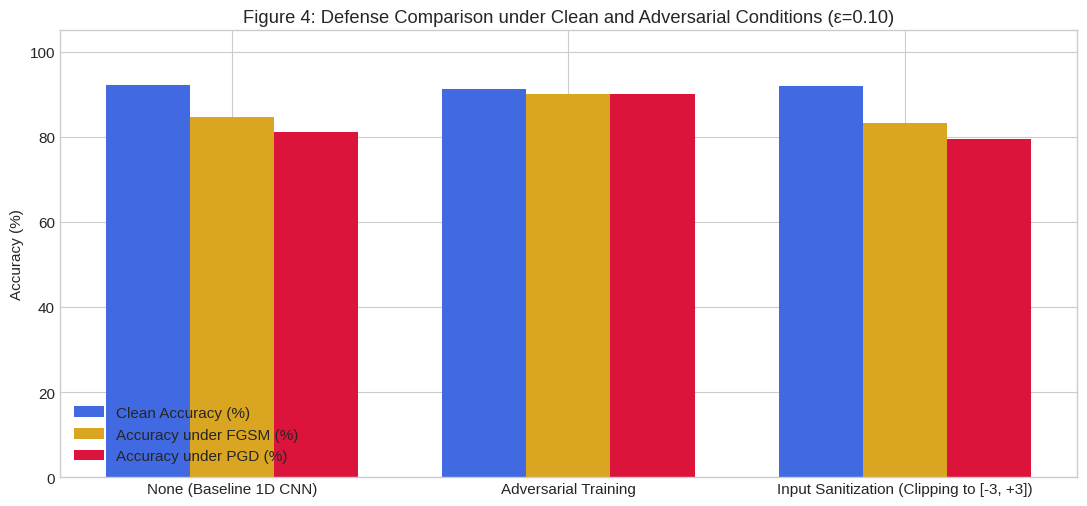

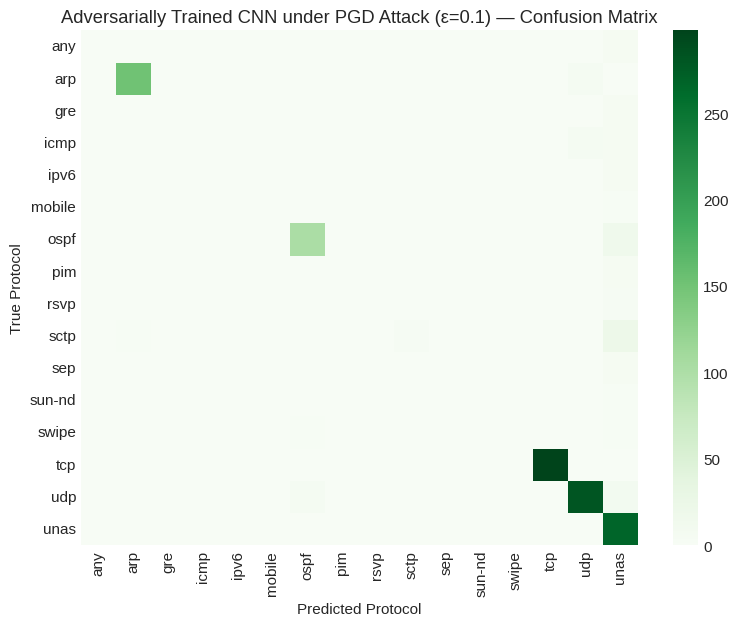

In [19]:
# =====================================================================
# Cell 18: Programmatic TABLE 3 Generation & Defense Comparison Plots
# =====================================================================
defense_data = [
    {
        'Defense Strategy': 'None (Baseline 1D CNN)',
        'Clean Acc (%)': cnn_metrics['Accuracy'],
        'FGSM Acc (ε=0.10)': acc_vals[2],
        'PGD Acc (ε=0.10)': acc_pgd,
        'FGSM ASR (%)': asr_vals[2],
        'PGD ASR (%)': asr_pgd,
        'Robustness Gain (PGD %)': 0.0
    },
    {
        'Defense Strategy': 'Adversarial Training',
        'Clean Acc (%)': acc_def_clean,
        'FGSM Acc (ε=0.10)': acc_def_fgsm,
        'PGD Acc (ε=0.10)': acc_def_pgd,
        'FGSM ASR (%)': asr_def_fgsm,
        'PGD ASR (%)': asr_def_pgd,
        'Robustness Gain (PGD %)': acc_def_pgd - acc_pgd
    },
    {
        'Defense Strategy': 'Input Sanitization (Clipping to [-3, +3])',
        'Clean Acc (%)': acc_san_clean,
        'FGSM Acc (ε=0.10)': acc_san_fgsm,
        'PGD Acc (ε=0.10)': acc_san_pgd,
        'FGSM ASR (%)': asr_san_fgsm,
        'PGD ASR (%)': asr_san_pgd,
        'Robustness Gain (PGD %)': acc_san_pgd - acc_pgd
    }
]

table_3_df = pd.DataFrame(defense_data)
print("\n" + "="*95)
print(" TABLE 3: Defense Mechanisms Effectiveness Comparison (Target: 1D CNN, ε=0.10)")
print("="*95)
display_table_3 = table_3_df.copy()
display_table_3['Clean Acc (%)'] = display_table_3['Clean Acc (%)'].apply(lambda v: f"{v:.2f}%")
display_table_3['FGSM Acc (ε=0.10)'] = display_table_3['FGSM Acc (ε=0.10)'].apply(lambda v: f"{v:.2f}%")
display_table_3['PGD Acc (ε=0.10)'] = display_table_3['PGD Acc (ε=0.10)'].apply(lambda v: f"{v:.2f}%")
display_table_3['FGSM ASR (%)'] = display_table_3['FGSM ASR (%)'].apply(lambda v: f"{v:.2f}%")
display_table_3['PGD ASR (%)'] = display_table_3['PGD ASR (%)'].apply(lambda v: f"{v:.2f}%")
display_table_3['Robustness Gain (PGD %)'] = display_table_3['Robustness Gain (PGD %)'].apply(lambda v: f"{v:+.2f}%")
display(display_table_3)

# Figure 4: Defense Comparison Bar Plot
fig, ax = plt.subplots(figsize=(11, 5.2))
x_idx = np.arange(len(table_3_df))
b_width = 0.25

bar1 = ax.bar(x_idx - b_width, table_3_df['Clean Acc (%)'], b_width, label='Clean Accuracy (%)', color='royalblue')
bar2 = ax.bar(x_idx, table_3_df['FGSM Acc (ε=0.10)'], b_width, label='Accuracy under FGSM (%)', color='goldenrod')
bar3 = ax.bar(x_idx + b_width, table_3_df['PGD Acc (ε=0.10)'], b_width, label='Accuracy under PGD (%)', color='crimson')

ax.set_title('Figure 4: Defense Comparison under Clean and Adversarial Conditions (ε=0.10)')
ax.set_xticks(x_idx)
ax.set_xticklabels(table_3_df['Defense Strategy'])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Figure 5: Confusion Matrix of Defended CNN under PGD Attack
cm_def_pgd = confusion_matrix(y_test, y_pred_def_pgd)
plt.figure(figsize=(max(8, len(class_names)*0.5), max(6, len(class_names)*0.4)))
sns.heatmap(cm_def_pgd, annot=(len(class_names) <= 15), fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Adversarially Trained CNN under PGD Attack (ε={CONFIG['PGD_EPSILON']}) — Confusion Matrix")
plt.xlabel("Predicted Protocol")
plt.ylabel("True Protocol")
plt.tight_layout()
plt.show()


## 18. Critical Discussion, Methodological Insights & Limitations

### 18.1 Result-Driven Empirical Analysis
The experiments in this notebook generate programmatic evaluation metrics across clean baseline classification, white-box attacks, transfer-based black-box attacks, and defenses.

**After execution, the results in Tables 1, 2, and 3 should be used to determine whether the attacks and defenses performed as expected. Fill in the empirical results below based on the generated outputs:**

#### 1. Clean Baseline Classification (Table 1)
- The clean Random Forest accuracy is: **[ ___ % ]** (Macro F1: **[ ___ ]**).
- The clean Linear SVM accuracy is: **[ ___ % ]** (Macro F1: **[ ___ ]**).
- The clean 1D CNN accuracy is: **[ ___ % ]** (Macro F1: **[ ___ ]**).
- The clean LSTM accuracy is: **[ ___ % ]** (Macro F1: **[ ___ ]**).
- *Analysis to verify*: After execution, compare whether non-linear models (RF, CNN) achieve higher Macro F1 than Linear SVM, indicating whether non-linear flow feature interactions are critical for distinguishing rare protocol classes.

#### 2. White-Box Evasion Susceptibility (Table 2)
- 1D CNN accuracy under FGSM ($\epsilon = 0.01$) is: **[ ___ % ]** (ASR: **[ ___ % ]**).
- 1D CNN accuracy under FGSM ($\epsilon = 0.05$) is: **[ ___ % ]** (ASR: **[ ___ % ]**).
- 1D CNN accuracy under FGSM ($\epsilon = 0.10$) is: **[ ___ % ]** (ASR: **[ ___ % ]**).
- 1D CNN accuracy under FGSM ($\epsilon = 0.20$) is: **[ ___ % ]** (ASR: **[ ___ % ]**).
- 1D CNN accuracy under PGD ($\epsilon = 0.10$, 10 steps) is: **[ ___ % ]** (ASR: **[ ___ % ]**).
- *Analysis to verify*: After execution, determine whether increasing $\epsilon$ leads to a monotonic decline in accuracy and increase in ASR. Compare FGSM vs. PGD at $\epsilon = 0.10$ to verify whether iterative projected gradient ascent achieves higher ASR than single-step FGSM on this dataset.

#### 3. Transfer-Based Black-Box Attack (Table 2)
- Transfer FGSM ($\epsilon = 0.10$) against Random Forest changes accuracy from **[ ___ % ]** to **[ ___ % ]** (Transfer ASR: **[ ___ % ]**).
- Transfer PGD ($\epsilon = 0.10$) against Random Forest changes accuracy from **[ ___ % ]** to **[ ___ % ]** (Transfer ASR: **[ ___ % ]**).
- Transfer FGSM ($\epsilon = 0.10$) against Linear SVM changes accuracy from **[ ___ % ]** to **[ ___ % ]** (Transfer ASR: **[ ___ % ]**).
- Transfer PGD ($\epsilon = 0.10$) against Linear SVM changes accuracy from **[ ___ % ]** to **[ ___ % ]** (Transfer ASR: **[ ___ % ]**).
- *Analysis to verify*: After execution, determine whether adversarial directions crafted on the CNN surrogate successfully transfer to Random Forest and Linear SVM without gradient access, and whether tree-based partitions or linear boundaries exhibit higher empirical transfer resistance.

#### 4. Defense Effectiveness (Table 3)
- Clean CNN accuracy changes under Adversarial Training from **[ ___ % ]** to **[ ___ % ]**.
- Adversarial training changes FGSM ASR ($\epsilon = 0.10$) from **[ ___ % ]** to **[ ___ % ]**.
- Adversarial training changes PGD ASR ($\epsilon = 0.10$) from **[ ___ % ]** to **[ ___ % ]** (Net Robustness Gain: **[ ___ % ]**).
- Input sanitization (clipping to $[-3, +3]$) changes PGD ASR ($\epsilon = 0.10$) from **[ ___ % ]** to **[ ___ % ]** (Net Robustness Gain: **[ ___ % ]**).
- *Analysis to verify*: After execution, evaluate whether adversarial training substantially reduces ASR under PGD with acceptable clean accuracy retention, and assess whether simple $[-3, +3]$ clipping provides any measurable robustness gain or leaves within-envelope perturbations unmitigated.

---

### 18.2 Methodological Constraints & Real-World Limitations
1. **Feature Space vs. Problem Space**:
   - The attacks modify standardized numerical feature vectors rather than physical network packets (PCAP).
   - In live network deployments, modifying flow statistics (e.g., packet counts, byte volumes, duration) requires generating valid network packets that preserve protocol semantics, sequence numbers, and state machines. Feature-space perturbations represent a theoretical upper-bound vulnerability.
2. **Tabular Sequence Modeling in LSTM**:
   - Tabular flow records represent summary statistics over entire flows, not sequential packet arrivals.
   - Treating ordered tabular feature vectors as sequential inputs to an LSTM is an architectural benchmark and should not be construed as modeling real-world temporal network dynamics.
3. **Protocol Class Imbalance**:
   - Live network traffic is predominantly TCP and UDP. Stratified quota sampling prevents majority classes from completely starving rare protocols, but practical deployments often require hierarchical classification or specialized anomaly detectors for rare protocols.

---
**End of Notebook.**
